# Provider Fraud Detection — Optimized EDA + Selective Features + Tuned Models

This notebook is the improved version of the earlier pipeline. It focuses on **quality features instead of too many features** and adds:

- Full EDA: shape, duplicates, missing values, target imbalance, provider repetition, outliers, heatmap
- Patient category feature: `Inpatient` / `Outpatient`
- Inpatient duration feature: `NoOfDaysAdmitted` from admission and discharge dates
- Selective domain-driven provider-level feature engineering
- KNN imputation inside ML pipeline
- Scaling only where required
- Imbalance handling using SMOTE and class weights
- Stratified train-test split and Stratified K-Fold CV
- Tuned Random Forest and XGBoost
- Logistic Regression and ANN-style MLPClassifier baseline
- Threshold tuning based on F1 / PR-AUC style fraud performance
- Final feature importance and model artifact saving

> Important: Since the target label is at **Provider level**, the final model is correctly trained at **one row per provider** level.

In [ ]:
# ===============================
# 1. Imports and Configuration
# ===============================

import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, average_precision_score,
    precision_recall_curve, roc_curve, f1_score, precision_score, recall_score, accuracy_score
)
from sklearn.feature_selection import VarianceThreshold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.neural_network import MLPClassifier

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

from xgboost import XGBClassifier

import joblib

pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 100)

RANDOM_STATE = 42
DATA_DIR = '/content'

In [ ]:
# ===============================
# 2. Load Data
# ===============================

beneficiary = pd.read_csv('/content/Train_Beneficiarydata-1542865627584.csv')
inpatient = pd.read_csv('/content/Train_Inpatientdata-1542865627584.csv')
outpatient = pd.read_csv('/content/Train_Outpatientdata-1542865627584.csv')
provider_label = pd.read_csv('/content/Train-1542865627584.csv')

print('Beneficiary shape:', beneficiary.shape)
print('Inpatient shape:', inpatient.shape)
print('Outpatient shape:', outpatient.shape)
print('Provider label shape:', provider_label.shape)

display(beneficiary.head())
display(inpatient.head())
display(outpatient.head())
display(provider_label.head())


Beneficiary shape: (138556, 25)
Inpatient shape: (40474, 30)
Outpatient shape: (517737, 27)
Provider label shape: (5410, 2)


,BeneID,DOB,DOD,Gender,Race,RenalDiseaseIndicator,State,County,NoOfMonths_PartACov,NoOfMonths_PartBCov,ChronicCond_Alzheimer,ChronicCond_Heartfailure,ChronicCond_KidneyDisease,ChronicCond_Cancer,ChronicCond_ObstrPulmonary,ChronicCond_Depression,ChronicCond_Diabetes,ChronicCond_IschemicHeart,ChronicCond_Osteoporasis,ChronicCond_rheumatoidarthritis,ChronicCond_stroke,IPAnnualReimbursementAmt,IPAnnualDeductibleAmt,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt
0,BENE11001,1943-01-01,NaN,1,1,0,39,230,12,12,1,2,1,2,2,1,1,1,2,1,1,36000,3204,60,70
1,BENE11002,1936-09-01,NaN,2,1,0,39,280,12,12,2,2,2,2,2,2,2,2,2,2,2,0,0,30,50
2,BENE11003,1936-08-01,NaN,1,1,0,52,590,12,12,1,2,2,2,2,2,2,1,2,2,2,0,0,90,40
3,BENE11004,1922-07-01,NaN,1,1,0,39,270,12,12,1,1,2,2,2,2,1,1,1,1,2,0,0,1810,760
4,BENE11005,1935-09-01,NaN,1,1,0,24,680,12,12,2,2,2,2,1,2,1,2,2,2,2,0,0,1790,1200


,BeneID,ClaimID,ClaimStartDt,ClaimEndDt,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,OtherPhysician,AdmissionDt,ClmAdmitDiagnosisCode,DeductibleAmtPaid,DischargeDt,DiagnosisGroupCode,ClmDiagnosisCode_1,ClmDiagnosisCode_2,ClmDiagnosisCode_3,ClmDiagnosisCode_4,ClmDiagnosisCode_5,ClmDiagnosisCode_6,ClmDiagnosisCode_7,ClmDiagnosisCode_8,ClmDiagnosisCode_9,ClmDiagnosisCode_10,ClmProcedureCode_1,ClmProcedureCode_2,ClmProcedureCode_3,ClmProcedureCode_4,ClmProcedureCode_5,ClmProcedureCode_6
0,BENE11001,CLM46614,2009-04-12,2009-04-18,PRV55912,26000,PHY390922,NaN,NaN,2009-04-12,7866,1068.0,2009-04-18,201,1970,4019,5853,7843,2768,71590,2724,19889,5849,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,BENE11001,CLM66048,2009-08-31,2009-09-02,PRV55907,5000,PHY318495,PHY318495,NaN,2009-08-31,6186,1068.0,2009-09-02,750,6186,2948,56400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7092.0,NaN,NaN,NaN,NaN,NaN
2,BENE11001,CLM68358,2009-09-17,2009-09-20,PRV56046,5000,PHY372395,NaN,PHY324689,2009-09-17,29590,1068.0,2009-09-20,883,29623,30390,71690,34590,V1581,32723,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,BENE11011,CLM38412,2009-02-14,2009-02-22,PRV52405,5000,PHY369659,PHY392961,PHY349768,2009-02-14,431,1068.0,2009-02-22,067,43491,2762,7843,32723,V1041,4254,25062,40390,4019,NaN,331.0,NaN,NaN,NaN,NaN,NaN
4,BENE11014,CLM63689,2009-08-13,2009-08-30,PRV56614,10000,PHY379376,PHY398258,NaN,2009-08-13,78321,1068.0,2009-08-30,975,042,3051,34400,5856,42732,486,5119,29620,20300,NaN,3893.0,NaN,NaN,NaN,NaN,NaN


,BeneID,ClaimID,ClaimStartDt,ClaimEndDt,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,OtherPhysician,ClmDiagnosisCode_1,ClmDiagnosisCode_2,ClmDiagnosisCode_3,ClmDiagnosisCode_4,ClmDiagnosisCode_5,ClmDiagnosisCode_6,ClmDiagnosisCode_7,ClmDiagnosisCode_8,ClmDiagnosisCode_9,ClmDiagnosisCode_10,ClmProcedureCode_1,ClmProcedureCode_2,ClmProcedureCode_3,ClmProcedureCode_4,ClmProcedureCode_5,ClmProcedureCode_6,DeductibleAmtPaid,ClmAdmitDiagnosisCode
0,BENE11002,CLM624349,2009-10-11,2009-10-11,PRV56011,30,PHY326117,NaN,NaN,78943,V5866,V1272,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,56409
1,BENE11003,CLM189947,2009-02-12,2009-02-12,PRV57610,80,PHY362868,NaN,NaN,6115,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,79380
2,BENE11003,CLM438021,2009-06-27,2009-06-27,PRV57595,10,PHY328821,NaN,NaN,2723,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN
3,BENE11004,CLM121801,2009-01-06,2009-01-06,PRV56011,40,PHY334319,NaN,NaN,71988,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN
4,BENE11004,CLM150998,2009-01-22,2009-01-22,PRV56011,200,PHY403831,NaN,NaN,82382,30000,72887,4280,7197,V4577,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,71947


,Provider,PotentialFraud
0,PRV51001,No
1,PRV51003,Yes
2,PRV51004,No
3,PRV51005,Yes
4,PRV51007,No


## 3. Basic EDA: Missing Values, Duplicates, Target Imbalance

Beneficiary
Shape: (138556, 25)
Duplicate rows: 0

Beneficiary missing summary: 1 columns with missing values


,missing_count,missing_percent
DOD,137135,98.97


Inpatient
Shape: (40474, 30)
Duplicate rows: 0

Inpatient missing summary: 19 columns with missing values


,missing_count,missing_percent
ClmProcedureCode_6,40474,100.00
ClmProcedureCode_5,40465,99.98
ClmProcedureCode_4,40358,99.71
ClmProcedureCode_3,39509,97.62
ClmDiagnosisCode_10,36547,90.30
OtherPhysician,35784,88.41
ClmProcedureCode_2,35020,86.52
ClmProcedureCode_1,17326,42.81
OperatingPhysician,16644,41.12
ClmDiagnosisCode_9,13497,33.35


Outpatient
Shape: (517737, 27)
Duplicate rows: 0

Outpatient missing summary: 20 columns with missing values


...

Provider Label
Shape: (5410, 2)
Duplicate rows: 0

Provider Label missing summary: 0 columns with missing values


,missing_count,missing_percent


Target distribution:


,count
PotentialFraud,
No,4904
Yes,506


,proportion
PotentialFraud,
No,90.65
Yes,9.35


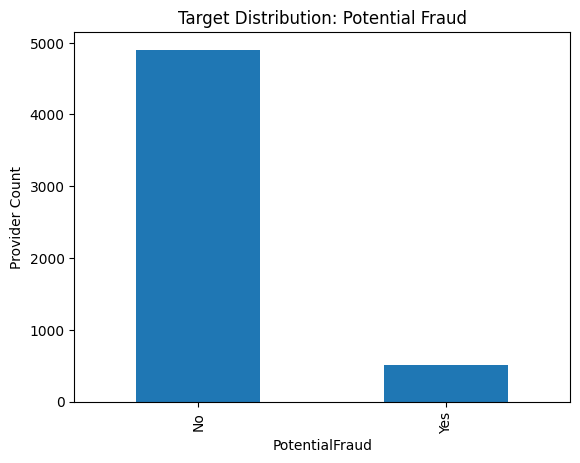

In [ ]:
def missing_summary(df, name):
    miss = df.isnull().sum().sort_values(ascending=False)
    miss_pct = (miss / len(df) * 100).round(2)
    out = pd.DataFrame({'missing_count': miss, 'missing_percent': miss_pct})
    out = out[out['missing_count'] > 0]
    print(f"\n{name} missing summary: {out.shape[0]} columns with missing values")
    display(out.head(30))

for df, name in [(beneficiary, 'Beneficiary'), (inpatient, 'Inpatient'), (outpatient, 'Outpatient'), (provider_label, 'Provider Label')]:
    print('='*80)
    print(name)
    print('Shape:', df.shape)
    print('Duplicate rows:', df.duplicated().sum())
    missing_summary(df, name)

print('Target distribution:')
display(provider_label['PotentialFraud'].value_counts())
display(provider_label['PotentialFraud'].value_counts(normalize=True).mul(100).round(2))

provider_label['PotentialFraud'].value_counts().plot(kind='bar', title='Target Distribution: Potential Fraud')
plt.ylabel('Provider Count')
plt.show()


## 4. Provider Repetition Analysis

This checks whether providers appear repetitively in claims. This is expected because one provider can file many claims. Fraud prediction should therefore be aggregated at provider level.

Unique providers in label file: 5410
Unique providers in inpatient: 2092
Unique providers in outpatient: 5012
Top 10 repetitive providers by total claims:


,InpatientClaimCount,OutpatientClaimCount,TotalClaims,Provider,PotentialFraud
363,0.0,8240.0,8240.0,PRV51459,Yes
2250,0.0,4739.0,4739.0,PRV53797,Yes
455,0.0,4444.0,4444.0,PRV51574,Yes
2335,0.0,3588.0,3588.0,PRV53918,Yes
3113,3.0,3433.0,3436.0,PRV54895,Yes
3363,143.0,3250.0,3393.0,PRV55215,Yes
853,38.0,2806.0,2844.0,PRV52064,Yes
4004,0.0,2833.0,2833.0,PRV56011,Yes
3195,3.0,2396.0,2399.0,PRV55004,Yes
5032,0.0,2315.0,2315.0,PRV57306,Yes


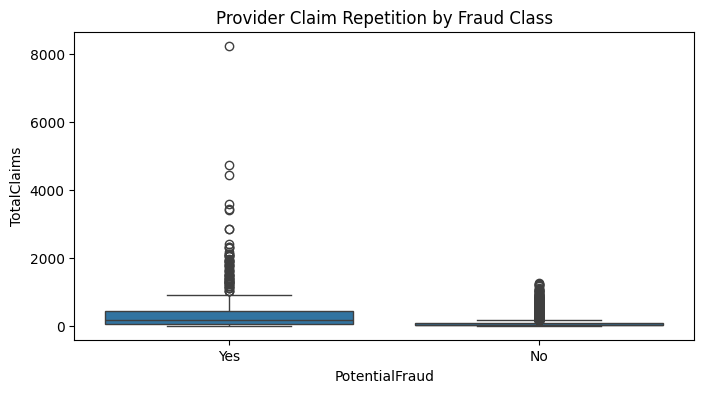

In [ ]:
print('Unique providers in label file:', provider_label['Provider'].nunique())
print('Unique providers in inpatient:', inpatient['Provider'].nunique())
print('Unique providers in outpatient:', outpatient['Provider'].nunique())

inp_provider_counts = inpatient['Provider'].value_counts().rename('InpatientClaimCount')
out_provider_counts = outpatient['Provider'].value_counts().rename('OutpatientClaimCount')
provider_repetition = pd.concat([inp_provider_counts, out_provider_counts], axis=1).fillna(0)
provider_repetition['TotalClaims'] = provider_repetition['InpatientClaimCount'] + provider_repetition['OutpatientClaimCount']
provider_repetition = provider_repetition.merge(provider_label, left_index=True, right_on='Provider', how='left')

print('Top 10 repetitive providers by total claims:')
display(provider_repetition.sort_values('TotalClaims', ascending=False).head(10))

plt.figure(figsize=(8,4))
sns.boxplot(data=provider_repetition, x='PotentialFraud', y='TotalClaims')
plt.title('Provider Claim Repetition by Fraud Class')
plt.show()


## 5. Date Processing + Patient Category + Admission Duration

In [ ]:
# Convert claim and admission dates
for df in [inpatient, outpatient]:
    df['ClaimStartDt'] = pd.to_datetime(df['ClaimStartDt'], errors='coerce')
    df['ClaimEndDt'] = pd.to_datetime(df['ClaimEndDt'], errors='coerce')

inpatient['AdmissionDt'] = pd.to_datetime(inpatient['AdmissionDt'], errors='coerce')
inpatient['DischargeDt'] = pd.to_datetime(inpatient['DischargeDt'], errors='coerce')

beneficiary['DOB'] = pd.to_datetime(beneficiary['DOB'], errors='coerce')
beneficiary['DOD'] = pd.to_datetime(beneficiary['DOD'], errors='coerce')

# Patient category
inpatient['PatientCategory'] = 'Inpatient'
outpatient['PatientCategory'] = 'Outpatient'

# No. of admitted days for inpatient. If same-day admission/discharge, count as 1 day.
inpatient['NoOfDaysAdmitted'] = (inpatient['DischargeDt'] - inpatient['AdmissionDt']).dt.days + 1
inpatient['NoOfDaysAdmitted'] = inpatient['NoOfDaysAdmitted'].clip(lower=0)

# Claim duration for both inpatient and outpatient
inpatient['ClaimDurationDays'] = (inpatient['ClaimEndDt'] - inpatient['ClaimStartDt']).dt.days + 1
outpatient['ClaimDurationDays'] = (outpatient['ClaimEndDt'] - outpatient['ClaimStartDt']).dt.days + 1

inpatient[['AdmissionDt','DischargeDt','NoOfDaysAdmitted','ClaimStartDt','ClaimEndDt','ClaimDurationDays','PatientCategory']].head()


,AdmissionDt,DischargeDt,NoOfDaysAdmitted,ClaimStartDt,ClaimEndDt,ClaimDurationDays,PatientCategory
0,2009-04-12,2009-04-18,7,2009-04-12,2009-04-18,7,Inpatient
1,2009-08-31,2009-09-02,3,2009-08-31,2009-09-02,3,Inpatient
2,2009-09-17,2009-09-20,4,2009-09-17,2009-09-20,4,Inpatient
3,2009-02-14,2009-02-22,9,2009-02-14,2009-02-22,9,Inpatient
4,2009-08-13,2009-08-30,18,2009-08-13,2009-08-30,18,Inpatient


## 6. Beneficiary Feature Cleaning and Health Feature Creation

In [ ]:
# Create beneficiary age at claim-time later; also create static beneficiary features
beneficiary['IsDead'] = beneficiary['DOD'].notna().astype(int)

# Convert chronic condition columns. In this dataset, 1 generally indicates condition present, 2 means not present.
chronic_cols = [c for c in beneficiary.columns if c.startswith('ChronicCond_')]
for c in chronic_cols:
    beneficiary[c] = beneficiary[c].replace({2:0}).fillna(0).astype(int)
beneficiary['ChronicConditionCount'] = beneficiary[chronic_cols].sum(axis=1)

# Renal disease indicator cleanup
beneficiary['RenalDiseaseIndicator'] = beneficiary['RenalDiseaseIndicator'].replace({'Y':1, '0':0, 0:0, 1:1}).fillna(0).astype(int)

beneficiary_selected = beneficiary[[
    'BeneID','DOB','DOD','Gender','Race','RenalDiseaseIndicator','State','County',
    'NoOfMonths_PartACov','NoOfMonths_PartBCov','ChronicConditionCount','IsDead'
]].copy()

display(beneficiary_selected.head())


,BeneID,DOB,DOD,Gender,Race,RenalDiseaseIndicator,State,County,NoOfMonths_PartACov,NoOfMonths_PartBCov,ChronicConditionCount,IsDead
0,BENE11001,1943-01-01,NaT,1,1,0,39,230,12,12,7,0
1,BENE11002,1936-09-01,NaT,2,1,0,39,280,12,12,0,0
2,BENE11003,1936-08-01,NaT,1,1,0,52,590,12,12,2,0
3,BENE11004,1922-07-01,NaT,1,1,0,39,270,12,12,6,0
4,BENE11005,1935-09-01,NaT,1,1,0,24,680,12,12,2,0


## 7. Combine Inpatient and Outpatient Claims

We combine both claim datasets and keep only meaningful raw columns required for domain-driven provider-level features.

In [ ]:
# Align columns before concatenation
all_claim_cols = sorted(set(inpatient.columns).union(set(outpatient.columns)))
inp_aligned = inpatient.reindex(columns=all_claim_cols)
out_aligned = outpatient.reindex(columns=all_claim_cols)
claims = pd.concat([inp_aligned, out_aligned], ignore_index=True)

# Merge beneficiary details
claims = claims.merge(beneficiary_selected, on='BeneID', how='left')

# Age at claim start
claims['AgeAtClaim'] = ((claims['ClaimStartDt'] - claims['DOB']).dt.days / 365.25).clip(lower=0)

# Missing financial values become zero where applicable
for col in ['InscClaimAmtReimbursed', 'DeductibleAmtPaid', 'NoOfDaysAdmitted', 'ClaimDurationDays']:
    if col in claims.columns:
        claims[col] = claims[col].fillna(0)

print('Combined claims shape:', claims.shape)
display(claims[['Provider','BeneID','ClaimID','PatientCategory','InscClaimAmtReimbursed','DeductibleAmtPaid','NoOfDaysAdmitted','ClaimDurationDays','AgeAtClaim']].head())


Combined claims shape: (558211, 45)


,Provider,BeneID,ClaimID,PatientCategory,InscClaimAmtReimbursed,DeductibleAmtPaid,NoOfDaysAdmitted,ClaimDurationDays,AgeAtClaim
0,PRV55912,BENE11001,CLM46614,Inpatient,26000,1068.0,7.0,7,66.277892
1,PRV55907,BENE11001,CLM66048,Inpatient,5000,1068.0,3.0,3,66.663929
2,PRV56046,BENE11001,CLM68358,Inpatient,5000,1068.0,4.0,4,66.710472
3,PRV52405,BENE11011,CLM38412,Inpatient,5000,1068.0,9.0,9,94.959617
4,PRV56614,BENE11014,CLM63689,Inpatient,10000,1068.0,18.0,18,71.367556


## 8. Outlier Analysis

We inspect outliers but avoid blindly removing them because extreme billing values can be useful fraud signals.

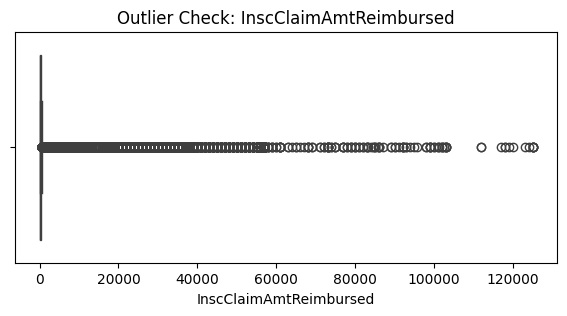

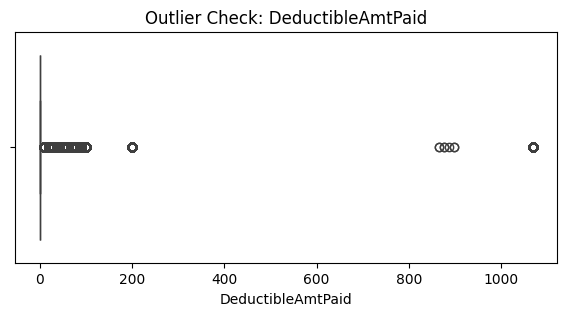

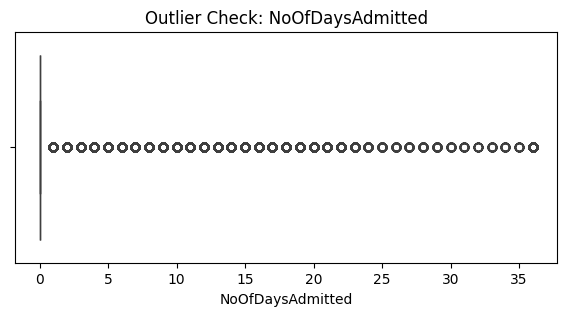

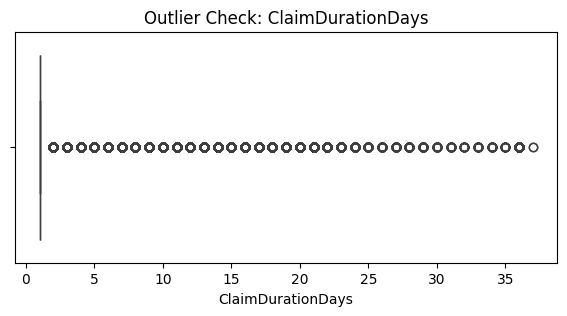

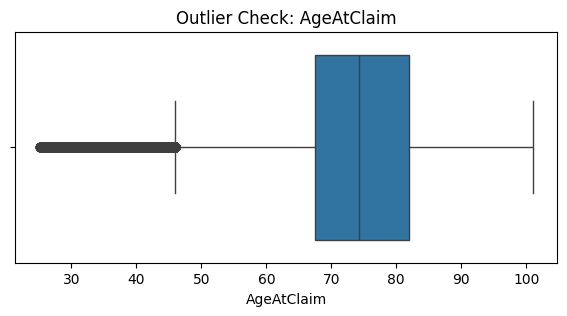

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
InscClaimAmtReimbursed,558211.0,997.012133,3821.534891,0.000000,0.000000,10.000000,40.000000,80.00000,300.000000,5000.000000,17000.000000,125000.00000
DeductibleAmtPaid,558211.0,78.294788,273.814128,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,1068.000000,1068.000000,1068.00000
NoOfDaysAdmitted,558211.0,0.483269,2.300583,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,4.000000,11.000000,36.00000
ClaimDurationDays,558211.0,2.727940,4.904984,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,18.000000,21.000000,37.00000
AgeAtClaim,558211.0,73.297705,13.017286,25.092402,32.829569,47.181383,67.542779,74.20397,81.954825,91.789185,98.811773,100.99384


In [ ]:
outlier_cols = ['InscClaimAmtReimbursed', 'DeductibleAmtPaid', 'NoOfDaysAdmitted', 'ClaimDurationDays', 'AgeAtClaim']
for col in outlier_cols:
    plt.figure(figsize=(7,3))
    sns.boxplot(x=claims[col])
    plt.title(f'Outlier Check: {col}')
    plt.show()

claims[outlier_cols].describe(percentiles=[0.01,0.05,0.25,0.5,0.75,0.95,0.99]).T


## 9. Optimized Domain-Driven Feature Engineering

Instead of using all aggregations, this section creates a compact set of strong fraud-behavior features.

Feature groups:
- Claim volume
- Patient reuse
- Financial billing behavior
- Admission behavior
- Diagnosis/procedure diversity without high-cardinality one-hot encoding
- Physician diversity
- Beneficiary health/demographic profile
- Behavioral ratios

In [ ]:
# Diagnosis and procedure columns
diag_cols = [c for c in claims.columns if 'ClmDiagnosisCode' in c or c == 'ClmAdmitDiagnosisCode']
proc_cols = [c for c in claims.columns if 'ClmProcedureCode' in c]
phys_cols = ['AttendingPhysician', 'OperatingPhysician', 'OtherPhysician']

# Claim-level helper flags
claims['IsInpatient'] = (claims['PatientCategory'] == 'Inpatient').astype(int)
claims['IsOutpatient'] = (claims['PatientCategory'] == 'Outpatient').astype(int)
claims['HasDeductible'] = (claims['DeductibleAmtPaid'] > 0).astype(int)
claims['HighReimbursementClaim'] = (claims['InscClaimAmtReimbursed'] > claims['InscClaimAmtReimbursed'].quantile(0.95)).astype(int)
claims['LongAdmissionClaim'] = (claims['NoOfDaysAdmitted'] > claims['NoOfDaysAdmitted'].quantile(0.95)).astype(int)

# Count non-null diagnosis/procedure codes per claim
claims['DiagnosisCodeCountPerClaim'] = claims[diag_cols].notna().sum(axis=1) if diag_cols else 0
claims['ProcedureCodeCountPerClaim'] = claims[proc_cols].notna().sum(axis=1) if proc_cols else 0
claims['PhysicianCountPerClaim'] = claims[phys_cols].notna().sum(axis=1)

# Provider-level core aggregation
provider_features = claims.groupby('Provider').agg(
    TotalClaims=('ClaimID','count'),
    UniquePatients=('BeneID','nunique'),
    InpatientClaimCount=('IsInpatient','sum'),
    OutpatientClaimCount=('IsOutpatient','sum'),

    TotalReimbursement=('InscClaimAmtReimbursed','sum'),
    AvgReimbursement=('InscClaimAmtReimbursed','mean'),
    MaxReimbursement=('InscClaimAmtReimbursed','max'),
    MedianReimbursement=('InscClaimAmtReimbursed','median'),

    TotalDeductible=('DeductibleAmtPaid','sum'),
    AvgDeductible=('DeductibleAmtPaid','mean'),
    DeductibleClaimRatio=('HasDeductible','mean'),

    AvgClaimDuration=('ClaimDurationDays','mean'),
    MaxClaimDuration=('ClaimDurationDays','max'),
    AvgAdmissionDays=('NoOfDaysAdmitted','mean'),
    MaxAdmissionDays=('NoOfDaysAdmitted','max'),
    LongAdmissionRatio=('LongAdmissionClaim','mean'),

    AvgDiagnosisCodesPerClaim=('DiagnosisCodeCountPerClaim','mean'),
    AvgProcedureCodesPerClaim=('ProcedureCodeCountPerClaim','mean'),
    AvgPhysicianCountPerClaim=('PhysicianCountPerClaim','mean'),

    AvgPatientAge=('AgeAtClaim','mean'),
    AvgChronicConditionCount=('ChronicConditionCount','mean'),
    RenalDiseasePatientRatio=('RenalDiseaseIndicator','mean'),
    DeadPatientRatio=('IsDead','mean'),
    MaleRatio=('Gender', lambda x: (x == 1).mean()),
    UniqueStates=('State','nunique'),
    UniqueCounties=('County','nunique'),

    HighReimbursementClaimRatio=('HighReimbursementClaim','mean')
).reset_index()

# Important behavioral ratios
provider_features['ClaimsPerPatient'] = provider_features['TotalClaims'] / provider_features['UniquePatients'].replace(0, np.nan)
provider_features['InpatientRatio'] = provider_features['InpatientClaimCount'] / provider_features['TotalClaims'].replace(0, np.nan)
provider_features['OutpatientRatio'] = provider_features['OutpatientClaimCount'] / provider_features['TotalClaims'].replace(0, np.nan)
provider_features['ReimbursementPerPatient'] = provider_features['TotalReimbursement'] / provider_features['UniquePatients'].replace(0, np.nan)
provider_features['DeductiblePerPatient'] = provider_features['TotalDeductible'] / provider_features['UniquePatients'].replace(0, np.nan)
provider_features['RepeatedPatientRatio'] = 1 - (provider_features['UniquePatients'] / provider_features['TotalClaims'].replace(0, np.nan))
provider_features['ReimbursementToDeductibleRatio'] = provider_features['TotalReimbursement'] / (provider_features['TotalDeductible'] + 1)
provider_features['AdmissionDaysPerClaim'] = provider_features['AvgAdmissionDays'] / (provider_features['AvgClaimDuration'] + 1)

# Diagnosis/procedure/physician diversity at provider level without one-hot encoding
def unique_values_across_columns(group, columns):
    if not columns:
        return 0
    vals = pd.unique(group[columns].values.ravel())
    vals = [v for v in vals if pd.notna(v)]
    return len(vals)

diversity_rows = []
for provider, grp in claims.groupby('Provider'):
    diversity_rows.append({
        'Provider': provider,
        'UniqueDiagnosisCodes': unique_values_across_columns(grp, diag_cols),
        'UniqueProcedureCodes': unique_values_across_columns(grp, proc_cols),
        'UniquePhysicians': unique_values_across_columns(grp, phys_cols),
    })
diversity_df = pd.DataFrame(diversity_rows)

provider_features = provider_features.merge(diversity_df, on='Provider', how='left')
provider_features['DiagnosisDiversityPerClaim'] = provider_features['UniqueDiagnosisCodes'] / provider_features['TotalClaims'].replace(0, np.nan)
provider_features['ProcedureDiversityPerClaim'] = provider_features['UniqueProcedureCodes'] / provider_features['TotalClaims'].replace(0, np.nan)
provider_features['PhysicianDiversityPerClaim'] = provider_features['UniquePhysicians'] / provider_features['TotalClaims'].replace(0, np.nan)

# Merge target
model_df = provider_features.merge(provider_label, on='Provider', how='inner')
model_df['Target'] = model_df['PotentialFraud'].map({'Yes':1, 'No':0})

print('Optimized provider-level dataframe shape:', model_df.shape)
print('Number of features excluding Provider, PotentialFraud, Target:', model_df.drop(columns=['Provider','PotentialFraud','Target']).shape[1])
display(model_df.head())


Optimized provider-level dataframe shape: (5410, 44)
Number of features excluding Provider, PotentialFraud, Target: 41


,Provider,TotalClaims,UniquePatients,InpatientClaimCount,OutpatientClaimCount,TotalReimbursement,AvgReimbursement,MaxReimbursement,MedianReimbursement,TotalDeductible,AvgDeductible,DeductibleClaimRatio,AvgClaimDuration,MaxClaimDuration,AvgAdmissionDays,MaxAdmissionDays,LongAdmissionRatio,AvgDiagnosisCodesPerClaim,AvgProcedureCodesPerClaim,AvgPhysicianCountPerClaim,AvgPatientAge,AvgChronicConditionCount,RenalDiseasePatientRatio,DeadPatientRatio,MaleRatio,UniqueStates,UniqueCounties,HighReimbursementClaimRatio,ClaimsPerPatient,InpatientRatio,OutpatientRatio,ReimbursementPerPatient,DeductiblePerPatient,RepeatedPatientRatio,ReimbursementToDeductibleRatio,AdmissionDaysPerClaim,UniqueDiagnosisCodes,UniqueProcedureCodes,UniquePhysicians,DiagnosisDiversityPerClaim,ProcedureDiversityPerClaim,PhysicianDiversityPerClaim,PotentialFraud,Target
0,PRV51001,25,24,5,20,104640,4185.600000,42000,400.0,5340.0,213.600000,0.200000,2.440000,15,1.200000,15.0,0.120000,3.640000,0.120000,1.600000,78.209446,5.560000,0.320000,0.000000,0.360000,1,7,0.120000,1.041667,0.200000,0.800000,4360.000000,222.500000,0.040000,19.591837,0.348837,83,3,19,3.320000,0.120000,0.760000,No,0
1,PRV51003,132,117,62,70,605670,4588.409091,57000,1750.0,66286.0,502.166667,0.477273,4.674242,28,2.893939,28.0,0.265152,5.840909,0.363636,1.530303,69.539792,4.545455,0.219697,0.007576,0.409091,3,23,0.318182,1.128205,0.469697,0.530303,5176.666667,566.547009,0.113636,9.137086,0.510013,394,39,51,2.984848,0.295455,0.386364,Yes,1
2,PRV51004,149,138,0,149,52170,350.134228,3300,70.0,310.0,2.080537,0.046980,2.429530,21,0.000000,0.0,0.000000,2.771812,0.000000,1.604027,71.738434,4.342282,0.154362,0.006711,0.308725,9,28,0.000000,1.079710,0.000000,1.000000,378.043478,2.246377,0.073826,167.749196,0.000000,283,0,48,1.899329,0.000000,0.322148,No,0
3,PRV51005,1165,495,0,1165,280910,241.124464,4080,70.0,3700.0,3.175966,0.041202,2.088412,21,0.000000,0.0,0.000000,2.805150,0.000000,1.599142,70.027283,4.335622,0.222318,0.003433,0.438627,4,26,0.000000,2.353535,0.000000,1.000000,567.494949,7.474747,0.575107,75.901108,0.000000,1348,0,7,1.157082,0.000000,0.006009,Yes,1
4,PRV51007,72,58,3,69,33710,468.194444,10000,80.0,3264.0,45.333333,0.069444,1.958333,21,0.263889,8.0,0.041667,3.222222,0.013889,1.527778,68.790174,4.166667,0.152778,0.013889,0.472222,2,6,0.027778,1.241379,0.041667,0.958333,581.206897,56.275862,0.194444,10.324655,0.089202,178,1,11,2.472222,0.013889,0.152778,No,0


## 10. Provider-Level Fraud EDA

Provider rows: 5410
Unique providers: 5410
Target distribution:


,count
PotentialFraud,
No,4904
Yes,506


,proportion
Target,
0,90.65
1,9.35


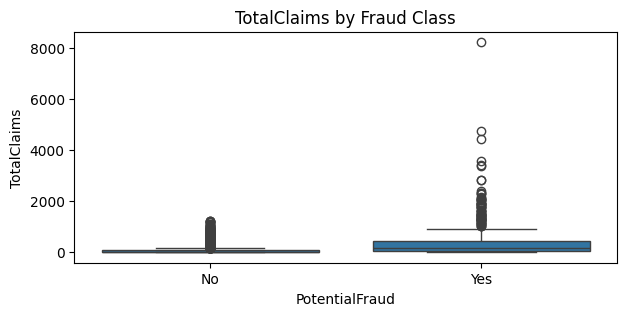

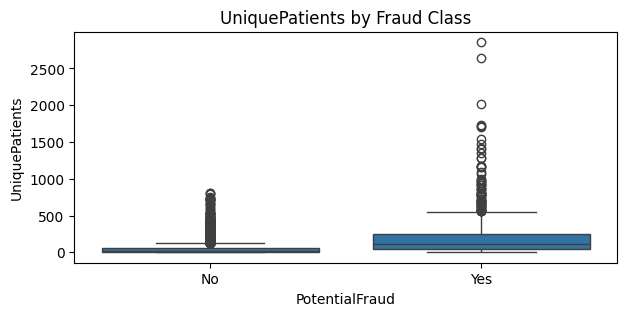

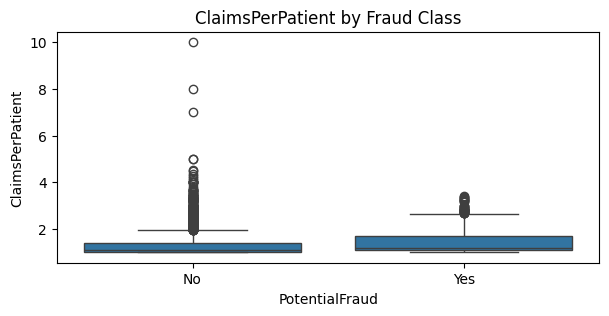

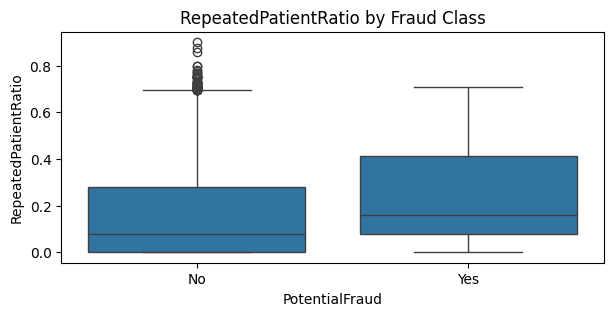

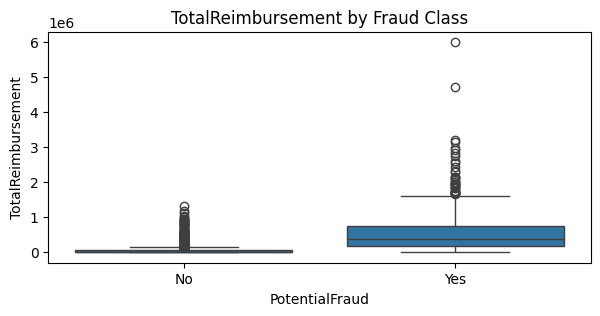

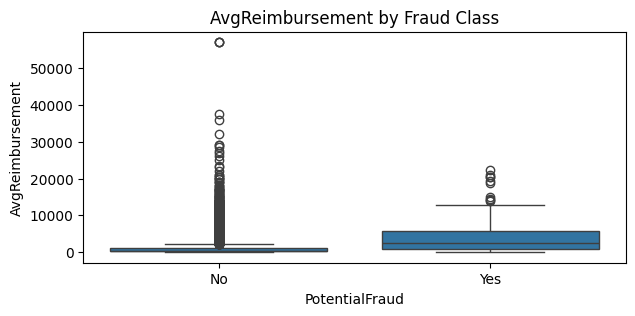

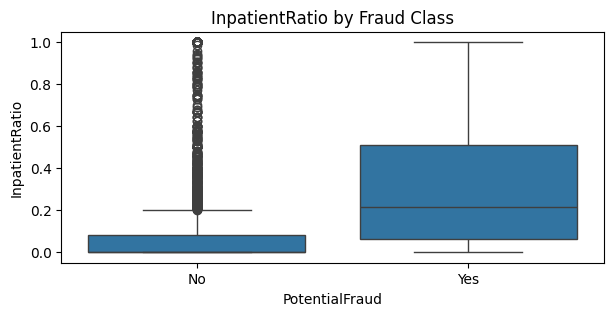

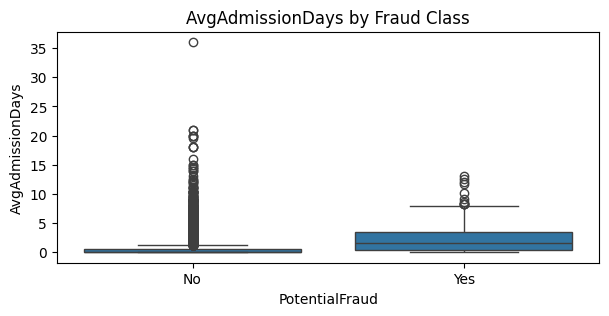

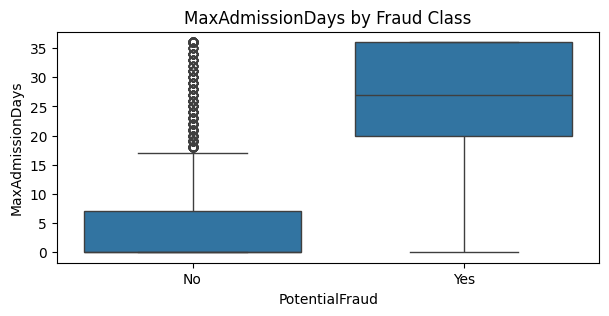

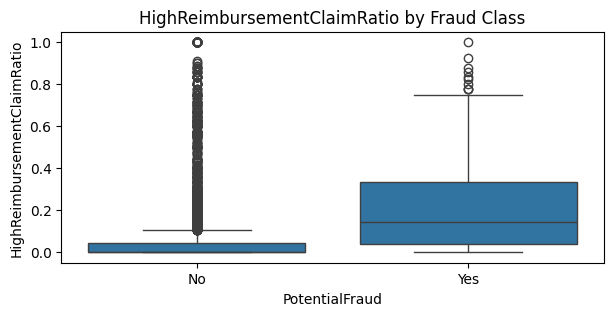

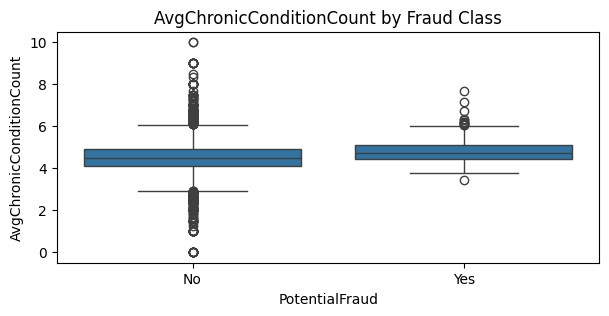

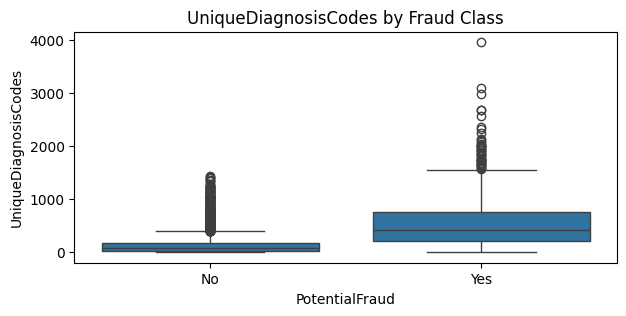

In [ ]:
print('Provider rows:', model_df.shape[0])
print('Unique providers:', model_df['Provider'].nunique())
print('Target distribution:')
display(model_df['PotentialFraud'].value_counts())
display(model_df['Target'].value_counts(normalize=True).mul(100).round(2))

eda_cols = [
    'TotalClaims','UniquePatients','ClaimsPerPatient','RepeatedPatientRatio','TotalReimbursement',
    'AvgReimbursement','InpatientRatio','AvgAdmissionDays','MaxAdmissionDays',
    'HighReimbursementClaimRatio','AvgChronicConditionCount','UniqueDiagnosisCodes'
]

for col in eda_cols:
    plt.figure(figsize=(7,3))
    sns.boxplot(data=model_df, x='PotentialFraud', y=col)
    plt.title(f'{col} by Fraud Class')
    plt.show()


## 11. Correlation Heatmap and Redundant Feature Removal

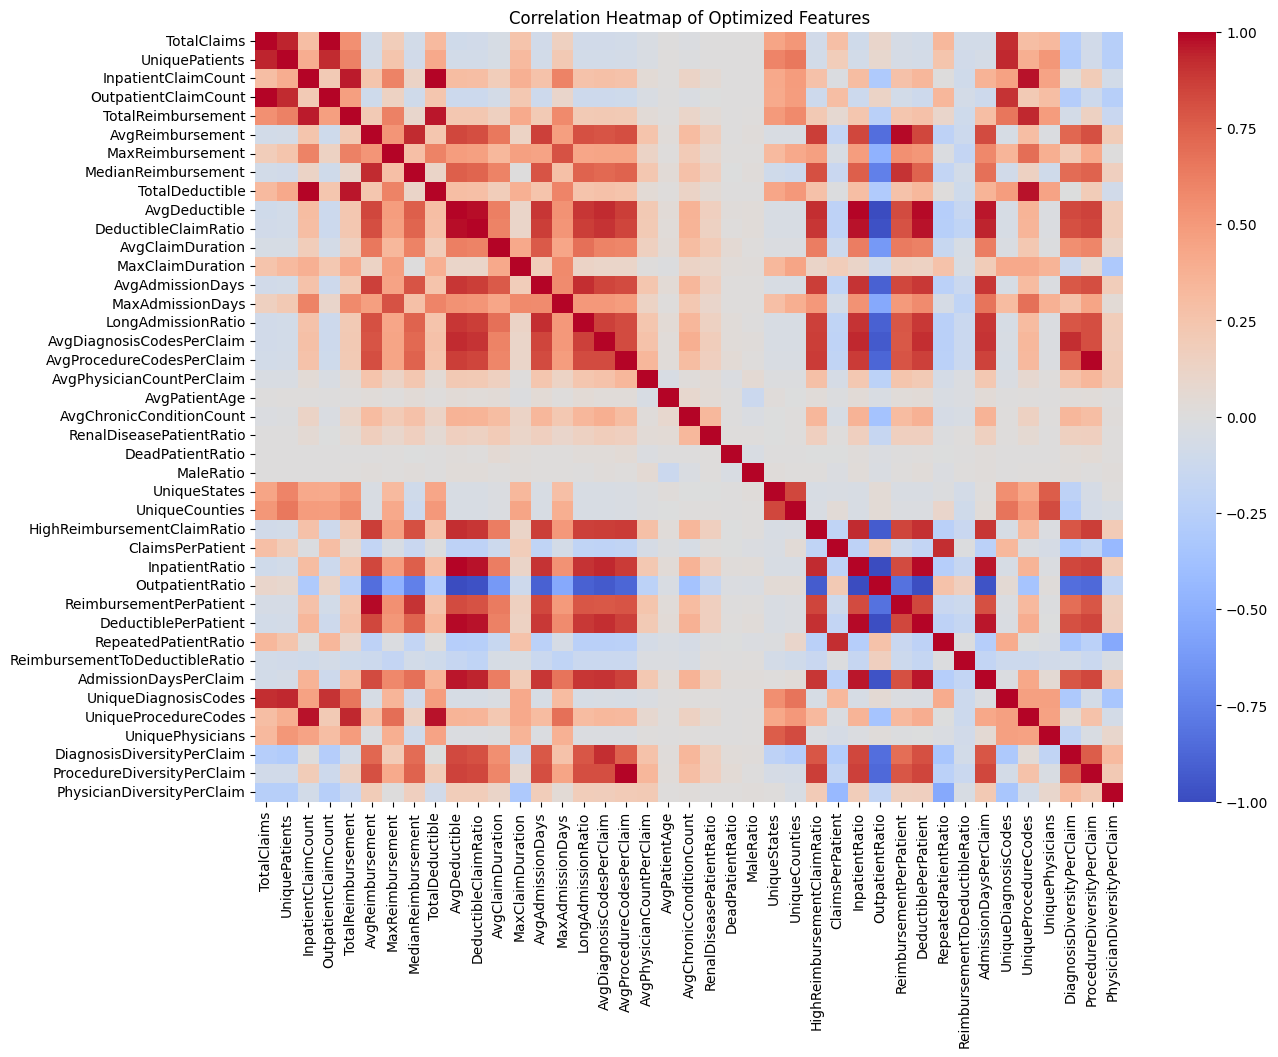

Highly correlated columns removed: ['UniquePatients', 'OutpatientClaimCount', 'TotalReimbursement', 'MedianReimbursement', 'TotalDeductible', 'DeductibleClaimRatio', 'AvgDiagnosisCodesPerClaim', 'InpatientRatio', 'OutpatientRatio', 'ReimbursementPerPatient', 'DeductiblePerPatient', 'AdmissionDaysPerClaim', 'UniqueDiagnosisCodes', 'UniqueProcedureCodes', 'ProcedureDiversityPerClaim']
Final feature count after correlation filtering: 26
Missing values before pipeline imputation: 0
Any infinite values remaining: False


In [ ]:
feature_cols = [c for c in model_df.columns if c not in ['Provider','PotentialFraud','Target']]
X_all = model_df[feature_cols].replace([np.inf, -np.inf], np.nan)
y = model_df['Target']

plt.figure(figsize=(14,10))
corr = X_all.corr(numeric_only=True)
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap of Optimized Features')
plt.show()

# Remove highly correlated features to reduce noise
def remove_high_corr_features(df, threshold=0.92):
    corr_matrix = df.corr(numeric_only=True).abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    drop_cols = [column for column in upper.columns if any(upper[column] > threshold)]
    return drop_cols

high_corr_drop = remove_high_corr_features(X_all, threshold=0.92)
print('Highly correlated columns removed:', high_corr_drop)

X = X_all.drop(columns=high_corr_drop)
print('Final feature count after correlation filtering:', X.shape[1])


# Final numeric safety check before splitting/modeling
X = X.apply(pd.to_numeric, errors='coerce')
X = X.replace([np.inf, -np.inf], np.nan)
print('Missing values before pipeline imputation:', int(X.isna().sum().sum()))
print('Any infinite values remaining:', bool(np.isinf(X.to_numpy(dtype=float, na_value=np.nan)).any()))


## 12. Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)
print('Train fraud ratio:', y_train.mean().round(4))
print('Test fraud ratio:', y_test.mean().round(4))


Train shape: (4328, 26)
Test shape: (1082, 26)
Train fraud ratio: 0.0936
Test fraud ratio: 0.0933


####tEtTETESSDFGERGFGDYHJFTJSDRRHDTFSSDRTHJSDFTKCDDSDGSADGSDFGDFD

In [ ]:
def find_best_threshold(y_true, y_prob, metric='f1'):
    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)
    thresholds = np.r_[thresholds, 1.0]

    f1_scores = 2 * precision * recall / (precision + recall + 1e-9)

    if metric == 'recall_precision_balance':
        score = f1_scores + 0.05 * recall
    else:
        score = f1_scores

    best_idx = np.nanargmax(score)

    return thresholds[best_idx], precision[best_idx], recall[best_idx], f1_scores[best_idx]


def get_model_scores(model, X_data):
    """Return fraud probabilities/scores safely for sklearn/imblearn pipelines."""
    if hasattr(model, 'predict_proba'):
        return model.predict_proba(X_data)[:, 1]
    return model.decision_function(X_data)


def evaluate_model(
    name,
    model,
    X_train,
    y_train,
    X_test,
    y_test,
    manual_threshold=0.65
):
    model.fit(X_train, y_train)

    y_prob = get_model_scores(model, X_test)

    # Manual threshold
    threshold = manual_threshold

    y_pred = (y_prob >= threshold).astype(int)

    results = {
        'Model': name,
        'Threshold': threshold,
        'ROC_AUC': roc_auc_score(y_test, y_prob),
        'PR_AUC': average_precision_score(y_test, y_prob),
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision_Fraud': precision_score(y_test, y_pred, zero_division=0),
        'Recall_Fraud': recall_score(y_test, y_pred, zero_division=0),
        'F1_Fraud': f1_score(y_test, y_pred, zero_division=0),
    }

    print('\n' + '=' * 80)
    print(name)
    print('Manual threshold:', threshold)
    print('ROC-AUC:', round(results['ROC_AUC'], 4))
    print('PR-AUC:', round(results['PR_AUC'], 4))

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=['Not Fraud', 'Potential Fraud'],
            zero_division=0
        )
    )

    cm = pd.DataFrame(
        confusion_matrix(y_test, y_pred),
        index=['Actual_NotFraud', 'Actual_Fraud'],
        columns=['Pred_NotFraud', 'Pred_Fraud']
    )

    display(cm)

    return results, y_prob, y_pred, model


def evaluate_model_auto_threshold(
    name,
    model,
    X_train,
    y_train,
    X_test,
    y_test,
    threshold_metric='f1'
):
    model.fit(X_train, y_train)

    y_prob = get_model_scores(model, X_test)

    threshold, p, r, f1 = find_best_threshold(
        y_test,
        y_prob,
        metric=threshold_metric
    )

    y_pred = (y_prob >= threshold).astype(int)

    results = {
        'Model': name,
        'BestThreshold': threshold,
        'ROC_AUC': roc_auc_score(y_test, y_prob),
        'PR_AUC': average_precision_score(y_test, y_prob),
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision_Fraud': precision_score(y_test, y_pred, zero_division=0),
        'Recall_Fraud': recall_score(y_test, y_pred, zero_division=0),
        'F1_Fraud': f1_score(y_test, y_pred, zero_division=0),
    }

    print('\n' + '=' * 80)
    print(name)
    print('Best threshold:', threshold)
    print('ROC-AUC:', round(results['ROC_AUC'], 4))
    print('PR-AUC:', round(results['PR_AUC'], 4))

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=['Not Fraud', 'Potential Fraud'],
            zero_division=0
        )
    )

    cm = pd.DataFrame(
        confusion_matrix(y_test, y_pred),
        index=['Actual_NotFraud', 'Actual_Fraud'],
        columns=['Pred_NotFraud', 'Pred_Fraud']
    )

    display(cm)

    return results, y_prob, y_pred, model


def threshold_comparison(y_test, y_prob, thresholds=[0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80]):
    threshold_results = []

    for threshold in thresholds:
        y_pred = (y_prob >= threshold).astype(int)

        threshold_results.append({
            'Threshold': threshold,
            'Accuracy': accuracy_score(y_test, y_pred),
            'Precision_Fraud': precision_score(y_test, y_pred, zero_division=0),
            'Recall_Fraud': recall_score(y_test, y_pred, zero_division=0),
            'F1_Fraud': f1_score(y_test, y_pred, zero_division=0),
            'False_Positives': confusion_matrix(y_test, y_pred)[0, 1],
            'False_Negatives': confusion_matrix(y_test, y_pred)[1, 0]
        })

    threshold_df = pd.DataFrame(threshold_results)
    display(threshold_df)

    return threshold_df


def cross_validate_model(name, model, X_train, y_train):
    cv = StratifiedKFold(
        n_splits=3,
        shuffle=True,
        random_state=RANDOM_STATE
    )

    scoring = {
        'roc_auc': 'roc_auc',
        'pr_auc': 'average_precision',
        'f1': 'f1',
        'recall': 'recall',
        'precision': 'precision'
    }

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=1,
        error_score='raise'
    )

    return {
        'Model': name,
        'CV_ROC_AUC_Mean': scores['test_roc_auc'].mean(),
        'CV_ROC_AUC_Std': scores['test_roc_auc'].std(),
        'CV_PR_AUC_Mean': scores['test_pr_auc'].mean(),
        'CV_PR_AUC_Std': scores['test_pr_auc'].std(),
        'CV_F1_Mean': scores['test_f1'].mean(),
        'CV_Recall_Mean': scores['test_recall'].mean(),
        'CV_Precision_Mean': scores['test_precision'].mean(),
    }

## 14. Build Baseline Pipelines

- Logistic Regression and ANN need scaling.
- Random Forest and XGBoost do not require scaling.
- KNNImputer is included in the pipeline.
- SMOTE is applied only inside training folds/pipeline to avoid leakage.

### Important Fix in This Version

This notebook uses flattened preprocessing pipelines. Some versions of `imbalanced-learn` throw `ValueError: All intermediate steps of the chain should not be Pipelines` when a sklearn `Pipeline` is placed inside an `ImbPipeline`.

So SMOTE models are written as:

`Imputer -> Scaler -> SMOTE -> Model`

instead of:

`Pipeline(Imputer + Scaler) -> SMOTE -> Model`

This fixes the cross-validation error and keeps preprocessing inside every CV fold.

In [ ]:

numeric_features = X.columns.tolist()

# Flattened pipelines are used because some imbalanced-learn versions do not allow
# a sklearn Pipeline object as an intermediate step inside ImbPipeline.
class_ratio = (y_train == 0).sum() / (y_train == 1).sum()
print('scale_pos_weight for XGBoost:', round(class_ratio, 2))

models = {
    'LogisticRegression_SMOTE': ImbPipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('smote', SMOTE(random_state=RANDOM_STATE, k_neighbors=3)),
        ('model', LogisticRegression(max_iter=3000, random_state=RANDOM_STATE))
    ]),

    'RandomForest_Balanced': Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('model', RandomForestClassifier(
            n_estimators=300,
            max_depth=None,
            min_samples_split=4,
            min_samples_leaf=2,
            max_features='sqrt',
            class_weight='balanced_subsample',
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ]),

    'XGBoost_Weighted': Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('model', XGBClassifier(
            n_estimators=300,
            max_depth=4,
            learning_rate=0.03,
            subsample=0.85,
            colsample_bytree=0.80,
            min_child_weight=3,
            gamma=0.1,
            reg_lambda=1.5,
            objective='binary:logistic',
            eval_metric='aucpr',
            scale_pos_weight=class_ratio,
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ]),

    'ANN_MLP_SMOTE': ImbPipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('smote', SMOTE(random_state=RANDOM_STATE, k_neighbors=3)),
        ('model', MLPClassifier(
            hidden_layer_sizes=(64, 32),
            activation='relu',
            solver='adam',
            alpha=0.001,
            learning_rate_init=0.001,
            max_iter=300,
            early_stopping=True,
            random_state=RANDOM_STATE
        ))
    ])
}


scale_pos_weight for XGBoost: 9.69


## 15. Cross-Validation Results

In [ ]:

cv_results = []
failed_models = []

for name, model in models.items():
    print('Cross-validating:', name)
    try:
        cv_results.append(cross_validate_model(name, model, X_train, y_train))
    except Exception as e:
        failed_models.append((name, str(e)))
        print(f'CV failed for {name}: {e}')

cv_df = pd.DataFrame(cv_results)
if not cv_df.empty:
    cv_df = cv_df.sort_values('CV_PR_AUC_Mean', ascending=False)
display(cv_df)

if failed_models:
    print('Models that failed during CV:')
    for name, err in failed_models:
        print(name, '->', err[:500])


Cross-validating: LogisticRegression_SMOTE
Cross-validating: RandomForest_Balanced
Cross-validating: XGBoost_Weighted
Cross-validating: ANN_MLP_SMOTE


,Model,CV_ROC_AUC_Mean,CV_ROC_AUC_Std,CV_PR_AUC_Mean,CV_PR_AUC_Std,CV_F1_Mean,CV_Recall_Mean,CV_Precision_Mean
2,XGBoost_Weighted,0.945610,0.012212,0.712689,0.030776,0.650648,0.814815,0.541620
1,RandomForest_Balanced,0.948747,0.008320,0.707704,0.024531,0.653131,0.622222,0.687852
0,LogisticRegression_SMOTE,0.943450,0.012075,0.702646,0.026153,0.599914,0.869136,0.458083
3,ANN_MLP_SMOTE,0.919974,0.010201,0.638456,0.034878,0.605200,0.666667,0.556170


## 16. Test Set Evaluation of Baseline/Tuned Models

In [ ]:

test_results = []
fitted_models = {}
model_probs = {}

for name, model in models.items():
    try:
        res, prob, pred, fitted = evaluate_model(name, model, X_train, y_train, X_test, y_test)
        test_results.append(res)
        fitted_models[name] = fitted
        model_probs[name] = prob
    except Exception as e:
        print(f'Evaluation failed for {name}: {e}')

results_df = pd.DataFrame(test_results).sort_values('PR_AUC', ascending=False)
display(results_df)



LogisticRegression_SMOTE
Manual threshold: 0.65
ROC-AUC: 0.9689
PR-AUC: 0.7805
                 precision    recall  f1-score   support

      Not Fraud       0.99      0.93      0.96       981
Potential Fraud       0.55      0.87      0.68       101

       accuracy                           0.92      1082
      macro avg       0.77      0.90      0.82      1082
   weighted avg       0.95      0.92      0.93      1082



,Pred_NotFraud,Pred_Fraud
Actual_NotFraud,910,71
Actual_Fraud,13,88



RandomForest_Balanced
Manual threshold: 0.65
ROC-AUC: 0.9713
PR-AUC: 0.7728
                 precision    recall  f1-score   support

      Not Fraud       0.95      0.99      0.97       981
Potential Fraud       0.81      0.48      0.60       101

       accuracy                           0.94      1082
      macro avg       0.88      0.73      0.78      1082
   weighted avg       0.94      0.94      0.93      1082



,Pred_NotFraud,Pred_Fraud
Actual_NotFraud,970,11
Actual_Fraud,53,48



XGBoost_Weighted
Manual threshold: 0.65
ROC-AUC: 0.9732
PR-AUC: 0.7934
                 precision    recall  f1-score   support

      Not Fraud       0.98      0.94      0.96       981
Potential Fraud       0.61      0.84      0.71       101

       accuracy                           0.94      1082
      macro avg       0.80      0.89      0.84      1082
   weighted avg       0.95      0.94      0.94      1082



,Pred_NotFraud,Pred_Fraud
Actual_NotFraud,927,54
Actual_Fraud,16,85



ANN_MLP_SMOTE
Manual threshold: 0.65
ROC-AUC: 0.9465
PR-AUC: 0.7103
                 precision    recall  f1-score   support

      Not Fraud       0.97      0.95      0.96       981
Potential Fraud       0.61      0.70      0.65       101

       accuracy                           0.93      1082
      macro avg       0.79      0.83      0.81      1082
   weighted avg       0.94      0.93      0.93      1082



,Pred_NotFraud,Pred_Fraud
Actual_NotFraud,936,45
Actual_Fraud,30,71


,Model,Threshold,ROC_AUC,PR_AUC,Accuracy,Precision_Fraud,Recall_Fraud,F1_Fraud
2,XGBoost_Weighted,0.65,0.973214,0.793355,0.935305,0.611511,0.841584,0.708333
0,LogisticRegression_SMOTE,0.65,0.968945,0.780494,0.922366,0.553459,0.871287,0.676923
1,RandomForest_Balanced,0.65,0.971326,0.772802,0.940850,0.813559,0.475248,0.600000
3,ANN_MLP_SMOTE,0.65,0.946478,0.710325,0.930684,0.612069,0.702970,0.654378


## 17. Hyperparameter Tuning for XGBoost

This section performs controlled tuning. It is intentionally not too large, so it remains practical to run.

In [ ]:

xgb_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('model', XGBClassifier(
        objective='binary:logistic',
        eval_metric='aucpr',
        scale_pos_weight=class_ratio,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

param_dist = {
    'model__n_estimators': [250, 350, 500, 650],
    'model__max_depth': [3, 4, 5, 6],
    'model__learning_rate': [0.01, 0.03, 0.05, 0.08],
    'model__subsample': [0.75, 0.85, 0.95],
    'model__colsample_bytree': [0.70, 0.80, 0.90],
    'model__min_child_weight': [1, 3, 5, 7],
    'model__gamma': [0, 0.05, 0.1, 0.2],
    'model__reg_lambda': [1, 1.5, 2, 3]
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

xgb_search = RandomizedSearchCV(
    estimator=xgb_pipe,
    param_distributions=param_dist,
    n_iter=10,
    scoring='average_precision',
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    error_score='raise'
)

xgb_search.fit(X_train, y_train)
print('Best XGBoost CV PR-AUC:', xgb_search.best_score_)
print('Best XGBoost params:')
print(xgb_search.best_params_)

xgb_tuned_res, xgb_tuned_prob, xgb_tuned_pred, xgb_tuned_model = evaluate_model(
    'XGBoost_Tuned', xgb_search.best_estimator_, X_train, y_train, X_test, y_test
)


Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best XGBoost CV PR-AUC: 0.722614072334146
Best XGBoost params:
{'model__subsample': 0.75, 'model__reg_lambda': 1.5, 'model__n_estimators': 650, 'model__min_child_weight': 3, 'model__max_depth': 6, 'model__learning_rate': 0.01, 'model__gamma': 0.05, 'model__colsample_bytree': 0.8}

XGBoost_Tuned
Manual threshold: 0.65
ROC-AUC: 0.974
PR-AUC: 0.7946
                 precision    recall  f1-score   support

      Not Fraud       0.98      0.96      0.97       981
Potential Fraud       0.65      0.80      0.72       101

       accuracy                           0.94      1082
      macro avg       0.82      0.88      0.84      1082
   weighted avg       0.95      0.94      0.94      1082



,Pred_NotFraud,Pred_Fraud
Actual_NotFraud,938,43
Actual_Fraud,20,81


## 18. Hyperparameter Tuning for Random Forest

In [ ]:
rf_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('model', RandomForestClassifier(
        class_weight='balanced_subsample',
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

rf_param_dist = {
    'model__n_estimators': [300, 500, 700],
    'model__max_depth': [None, 6, 8, 10, 12],
    'model__min_samples_split': [2, 4, 6, 10],
    'model__min_samples_leaf': [1, 2, 3, 5],
    'model__max_features': ['sqrt', 'log2', 0.5]
}

rf_search = RandomizedSearchCV(
    estimator=rf_pipe,
    param_distributions=rf_param_dist,
    n_iter=10,
    scoring='average_precision',
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    error_score='raise'
)

rf_search.fit(X_train, y_train)
print('Best RF CV PR-AUC:', rf_search.best_score_)
print('Best RF params:')
print(rf_search.best_params_)

rf_tuned_res, rf_tuned_prob, rf_tuned_pred, rf_tuned_model = evaluate_model(
    'RandomForest_Tuned', rf_search.best_estimator_, X_train, y_train, X_test, y_test
)


Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best RF CV PR-AUC: 0.7124741663346686
Best RF params:
{'model__n_estimators': 700, 'model__min_samples_split': 4, 'model__min_samples_leaf': 2, 'model__max_features': 'log2', 'model__max_depth': None}

RandomForest_Tuned
Manual threshold: 0.65
ROC-AUC: 0.9713
PR-AUC: 0.7615
                 precision    recall  f1-score   support

      Not Fraud       0.95      0.99      0.97       981
Potential Fraud       0.80      0.47      0.59       101

       accuracy                           0.94      1082
      macro avg       0.87      0.73      0.78      1082
   weighted avg       0.93      0.94      0.93      1082



,Pred_NotFraud,Pred_Fraud
Actual_NotFraud,969,12
Actual_Fraud,54,47


## 19. Soft Voting Ensemble

This combines tuned RF, tuned XGBoost, and Logistic Regression. Ensembles can improve stability and PR-AUC.

In [ ]:
# Use already defined strong models
lr_pipe = models['LogisticRegression_SMOTE']

voting_model = VotingClassifier(
    estimators=[
        ('lr', lr_pipe),
        ('rf', rf_search.best_estimator_),
        ('xgb', xgb_search.best_estimator_)
    ],
    voting='soft',
    weights=[1, 2, 2],
    n_jobs=1
)

# VotingClassifier cannot always nest imblearn pipelines with SMOTE reliably in CV in every environment,
# but it can be fit and evaluated here.
vote_res, vote_prob, vote_pred, vote_fitted = evaluate_model(
    'SoftVoting_LR_RF_XGB', voting_model, X_train, y_train, X_test, y_test
)



SoftVoting_LR_RF_XGB
Manual threshold: 0.65
ROC-AUC: 0.9737
PR-AUC: 0.7873
                 precision    recall  f1-score   support

      Not Fraud       0.97      0.97      0.97       981
Potential Fraud       0.71      0.74      0.72       101

       accuracy                           0.95      1082
      macro avg       0.84      0.86      0.85      1082
   weighted avg       0.95      0.95      0.95      1082



,Pred_NotFraud,Pred_Fraud
Actual_NotFraud,950,31
Actual_Fraud,26,75


## 20. Final Model Selection

In [ ]:
# =========================
# FINAL MODEL COMPARISON + BEST MODEL SELECTION
# =========================

final_results = pd.concat(
    [
        results_df,
        pd.DataFrame([xgb_tuned_res, rf_tuned_res, vote_res])
    ],
    ignore_index=True
)

# Fix threshold column mismatch
if 'BestThreshold' not in final_results.columns and 'Threshold' in final_results.columns:
    final_results['BestThreshold'] = final_results['Threshold']

if 'Threshold' not in final_results.columns and 'BestThreshold' in final_results.columns:
    final_results['Threshold'] = final_results['BestThreshold']

# If both exist but some values are missing
final_results['BestThreshold'] = final_results['BestThreshold'].fillna(final_results['Threshold'])
final_results['Threshold'] = final_results['Threshold'].fillna(final_results['BestThreshold'])

final_results = final_results.sort_values('PR_AUC', ascending=False)

display(final_results)

best_row = final_results.iloc[0]
best_model_name = best_row['Model']
best_threshold = best_row['BestThreshold']

print('Best model based on PR-AUC:', best_model_name)
print('Best threshold:', best_threshold)

model_lookup = {
    **fitted_models,
    'XGBoost_Tuned': xgb_tuned_model,
    'RandomForest_Tuned': rf_tuned_model,
    'SoftVoting_LR_RF_XGB': vote_fitted
}

prob_lookup = {
    **model_probs,
    'XGBoost_Tuned': xgb_tuned_prob,
    'RandomForest_Tuned': rf_tuned_prob,
    'SoftVoting_LR_RF_XGB': vote_prob
}

best_model = model_lookup[best_model_name]
best_prob = prob_lookup[best_model_name]

best_pred = (best_prob >= best_threshold).astype(int)

print('\nFinal Best Model Classification Report:\n')
print(
    classification_report(
        y_test,
        best_pred,
        target_names=['Not Fraud', 'Potential Fraud'],
        zero_division=0
    )
)

display(
    pd.DataFrame(
        confusion_matrix(y_test, best_pred),
        index=['Actual_NotFraud', 'Actual_Fraud'],
        columns=['Pred_NotFraud', 'Pred_Fraud']
    )
)


,Model,Threshold,ROC_AUC,PR_AUC,Accuracy,Precision_Fraud,Recall_Fraud,F1_Fraud,BestThreshold
4,XGBoost_Tuned,0.65,0.973991,0.794628,0.941774,0.653226,0.801980,0.720000,0.65
0,XGBoost_Weighted,0.65,0.973214,0.793355,0.935305,0.611511,0.841584,0.708333,0.65
6,SoftVoting_LR_RF_XGB,0.65,0.973688,0.787336,0.947320,0.707547,0.742574,0.724638,0.65
1,LogisticRegression_SMOTE,0.65,0.968945,0.780494,0.922366,0.553459,0.871287,0.676923,0.65
2,RandomForest_Balanced,0.65,0.971326,0.772802,0.940850,0.813559,0.475248,0.600000,0.65
5,RandomForest_Tuned,0.65,0.971276,0.761537,0.939002,0.796610,0.465347,0.587500,0.65
3,ANN_MLP_SMOTE,0.65,0.946478,0.710325,0.930684,0.612069,0.702970,0.654378,0.65


Best model based on PR-AUC: XGBoost_Tuned
Best threshold: 0.65

Final Best Model Classification Report:

                 precision    recall  f1-score   support

      Not Fraud       0.98      0.96      0.97       981
Potential Fraud       0.65      0.80      0.72       101

       accuracy                           0.94      1082
      macro avg       0.82      0.88      0.84      1082
   weighted avg       0.95      0.94      0.94      1082



,Pred_NotFraud,Pred_Fraud
Actual_NotFraud,938,43
Actual_Fraud,20,81


## 21. Precision-Recall Curve and ROC Curve

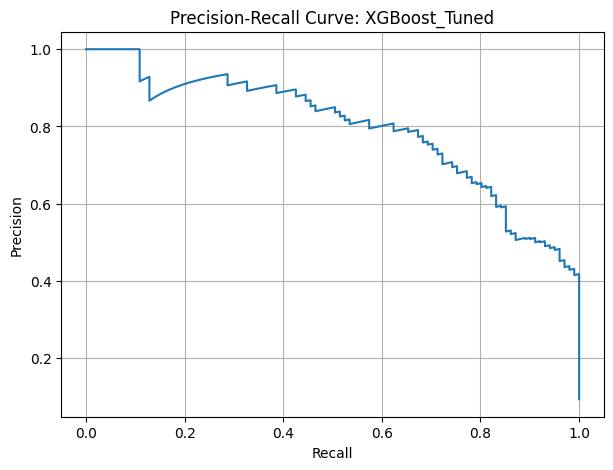

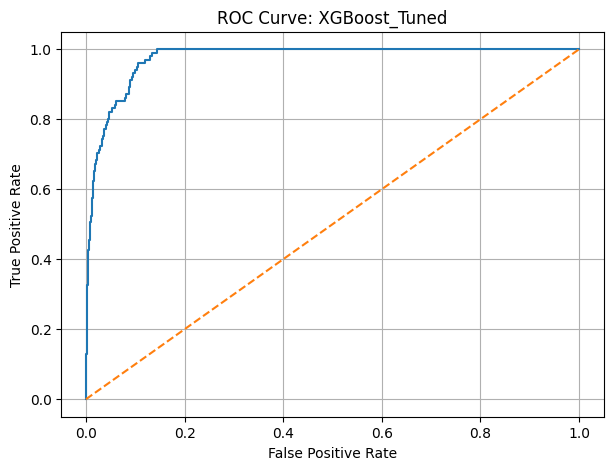

In [ ]:
plt.figure(figsize=(7,5))
precision, recall, _ = precision_recall_curve(y_test, best_prob)
plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(f'Precision-Recall Curve: {best_model_name}')
plt.grid(True)
plt.show()

plt.figure(figsize=(7,5))
fpr, tpr, _ = roc_curve(y_test, best_prob)
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve: {best_model_name}')
plt.grid(True)
plt.show()


## 22. Feature Importance

For tree models, feature importance helps explain which provider behaviors matter most. For ensemble, we show importance from tuned Random Forest and tuned XGBoost separately.

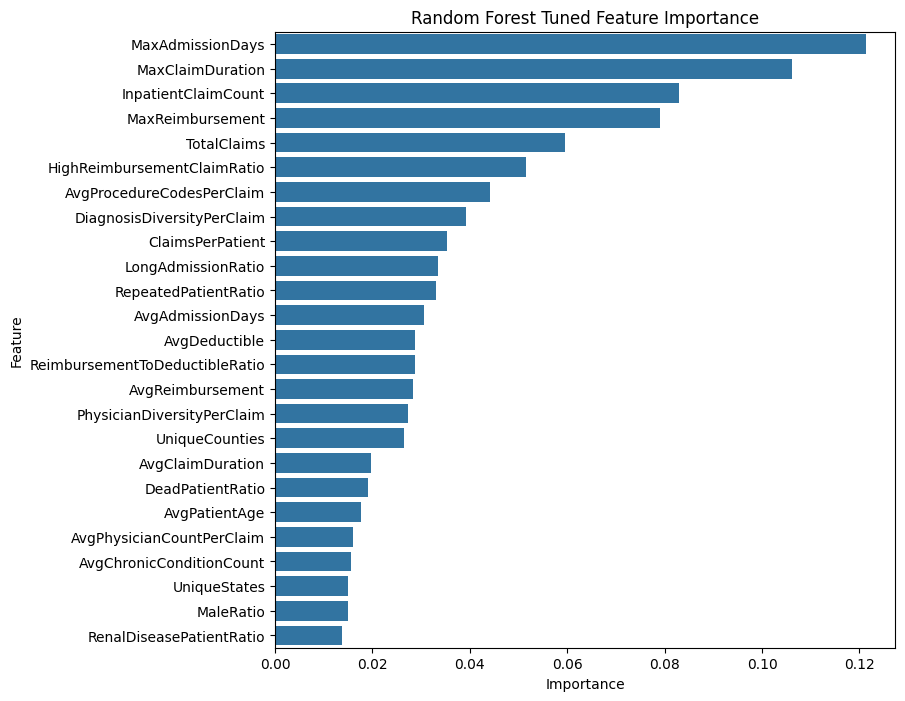

,Feature,Importance
8,MaxAdmissionDays,0.121252
6,MaxClaimDuration,0.106082
1,InpatientClaimCount,0.082950
3,MaxReimbursement,0.079105
0,TotalClaims,0.059521
19,HighReimbursementClaimRatio,0.051463
10,AvgProcedureCodesPerClaim,0.044051
24,DiagnosisDiversityPerClaim,0.039253
20,ClaimsPerPatient,0.035264
9,LongAdmissionRatio,0.033365


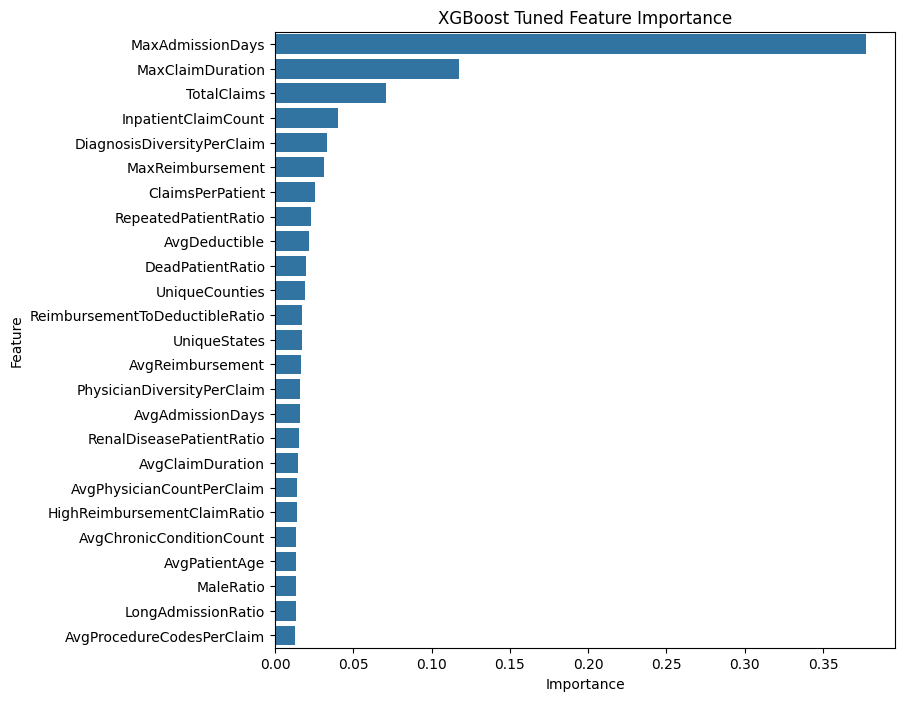

,Feature,Importance
8,MaxAdmissionDays,0.377091
6,MaxClaimDuration,0.117270
0,TotalClaims,0.070933
1,InpatientClaimCount,0.040193
24,DiagnosisDiversityPerClaim,0.033232
3,MaxReimbursement,0.031243
20,ClaimsPerPatient,0.025646
21,RepeatedPatientRatio,0.023145
4,AvgDeductible,0.021595
15,DeadPatientRatio,0.019503


In [ ]:
def plot_tree_importance(fitted_pipeline, title, top_n=25):
    try:
        model = fitted_pipeline.named_steps['model']
        importances = model.feature_importances_
        fi = pd.DataFrame({'Feature': X.columns, 'Importance': importances}).sort_values('Importance', ascending=False).head(top_n)
        plt.figure(figsize=(8,8))
        sns.barplot(data=fi, y='Feature', x='Importance')
        plt.title(title)
        plt.show()
        display(fi)
    except Exception as e:
        print('Could not plot importance:', e)

plot_tree_importance(rf_search.best_estimator_, 'Random Forest Tuned Feature Importance')
plot_tree_importance(xgb_search.best_estimator_, 'XGBoost Tuned Feature Importance')


## 23. Save Final Artifacts for Deployment

In [ ]:
import os
import joblib

# =========================
# SAVE MODEL ARTIFACTS
# =========================

ARTIFACT_DIR = os.path.join(
    DATA_DIR,
    'provider_fraud_optimized_artifacts'
)

os.makedirs(ARTIFACT_DIR, exist_ok=True)

# Save trained model
joblib.dump(
    best_model,
    os.path.join(
        ARTIFACT_DIR,
        'best_provider_fraud_model.pkl'
    )
)

# Save feature columns
joblib.dump(
    X.columns.tolist(),
    os.path.join(
        ARTIFACT_DIR,
        'final_feature_columns.pkl'
    )
)

# Save threshold
joblib.dump(
    float(best_threshold),
    os.path.join(
        ARTIFACT_DIR,
        'best_threshold.pkl'
    )
)

# Save model comparison dataframe
final_results.to_csv(
    os.path.join(
        ARTIFACT_DIR,
        'model_comparison_results.csv'
    ),
    index=False
)

# Save provider-level engineered dataset
model_df.to_csv(
    os.path.join(
        ARTIFACT_DIR,
        'provider_level_optimized_features.csv'
    ),
    index=False
)

print('Saved artifacts to:', ARTIFACT_DIR)

print('\nSaved Files:')

print(os.listdir(ARTIFACT_DIR))

Saved artifacts to: /content/provider_fraud_optimized_artifacts

Saved Files:
['model_comparison_results.csv', 'best_provider_fraud_model.pkl', 'final_feature_columns.pkl', 'best_threshold.pkl', 'provider_level_optimized_features.csv']


In [30]:
import os

for file in os.listdir('/content'):
    print('/content/' + file)

/content/.config
/content/Unseen_Beneficiarydata-1542969243754.csv
/content/provider_fraud_optimized_artifacts
/content/Train-1542865627584.csv
/content/.ipynb_checkpoints
/content/Train_Inpatientdata-1542865627584.csv
/content/Unseen_Outpatientdata-1542969243754.csv
/content/Train_Outpatientdata-1542865627584.csv
/content/Unseen_Inpatientdata-1542969243754.csv
/content/Unseen-1542969243754.csv
/content/Train_Beneficiarydata-1542865627584.csv
/content/sample_data


In [31]:
# =========================
# LOAD UNSEEN / TEST DATA
# =========================

unseen_provider = pd.read_csv(
    '/content/Unseen-1542969243754.csv'
)

unseen_inpatient = pd.read_csv(
    '/content/Unseen_Inpatientdata-1542969243754.csv'
)

unseen_outpatient = pd.read_csv(
    '/content/Unseen_Outpatientdata-1542969243754.csv'
)

unseen_beneficiary = pd.read_csv(
    '/content/Unseen_Beneficiarydata-1542969243754.csv'
)

print('Unseen provider shape:', unseen_provider.shape)
print('Unseen inpatient shape:', unseen_inpatient.shape)
print('Unseen outpatient shape:', unseen_outpatient.shape)
print('Unseen beneficiary shape:', unseen_beneficiary.shape)

Unseen provider shape: (1353, 1)
Unseen inpatient shape: (9551, 30)
Unseen outpatient shape: (125841, 27)
Unseen beneficiary shape: (63968, 25)


In [32]:
# =========================
# FEATURE ENGINEERING FOR UNSEEN DATA
# SAME LOGIC AS TRAINING
# =========================

def create_unseen_provider_features(inpatient, outpatient, beneficiary, provider_file):

    inpatient = inpatient.copy()
    outpatient = outpatient.copy()
    beneficiary = beneficiary.copy()
    provider_file = provider_file.copy()

    # Date processing
    for df in [inpatient, outpatient]:
        df['ClaimStartDt'] = pd.to_datetime(df['ClaimStartDt'], errors='coerce')
        df['ClaimEndDt'] = pd.to_datetime(df['ClaimEndDt'], errors='coerce')

    inpatient['AdmissionDt'] = pd.to_datetime(inpatient['AdmissionDt'], errors='coerce')
    inpatient['DischargeDt'] = pd.to_datetime(inpatient['DischargeDt'], errors='coerce')

    beneficiary['DOB'] = pd.to_datetime(beneficiary['DOB'], errors='coerce')
    beneficiary['DOD'] = pd.to_datetime(beneficiary['DOD'], errors='coerce')

    # Patient category
    inpatient['PatientCategory'] = 'Inpatient'
    outpatient['PatientCategory'] = 'Outpatient'

    # Admission duration
    inpatient['NoOfDaysAdmitted'] = (
        inpatient['DischargeDt'] - inpatient['AdmissionDt']
    ).dt.days + 1
    inpatient['NoOfDaysAdmitted'] = inpatient['NoOfDaysAdmitted'].clip(lower=0)

    outpatient['NoOfDaysAdmitted'] = 0

    # Claim duration
    inpatient['ClaimDurationDays'] = (
        inpatient['ClaimEndDt'] - inpatient['ClaimStartDt']
    ).dt.days + 1

    outpatient['ClaimDurationDays'] = (
        outpatient['ClaimEndDt'] - outpatient['ClaimStartDt']
    ).dt.days + 1

    # Beneficiary cleaning
    beneficiary['IsDead'] = beneficiary['DOD'].notna().astype(int)

    chronic_cols = [
        c for c in beneficiary.columns
        if c.startswith('ChronicCond_')
    ]

    for c in chronic_cols:
        beneficiary[c] = beneficiary[c].replace({2: 0}).fillna(0).astype(int)

    beneficiary['ChronicConditionCount'] = beneficiary[chronic_cols].sum(axis=1)

    beneficiary['RenalDiseaseIndicator'] = (
        beneficiary['RenalDiseaseIndicator']
        .replace({'Y': 1, '0': 0, 0: 0, 1: 1})
        .fillna(0)
        .astype(int)
    )

    beneficiary_selected = beneficiary[[
        'BeneID',
        'DOB',
        'DOD',
        'Gender',
        'Race',
        'RenalDiseaseIndicator',
        'State',
        'County',
        'NoOfMonths_PartACov',
        'NoOfMonths_PartBCov',
        'ChronicConditionCount',
        'IsDead'
    ]].copy()

    # Combine claims
    all_claim_cols = sorted(set(inpatient.columns).union(set(outpatient.columns)))

    inp_aligned = inpatient.reindex(columns=all_claim_cols)
    out_aligned = outpatient.reindex(columns=all_claim_cols)

    claims = pd.concat(
        [inp_aligned, out_aligned],
        ignore_index=True
    )

    claims = claims.merge(
        beneficiary_selected,
        on='BeneID',
        how='left'
    )

    claims['AgeAtClaim'] = (
        (claims['ClaimStartDt'] - claims['DOB']).dt.days / 365.25
    ).clip(lower=0)

    for col in [
        'InscClaimAmtReimbursed',
        'DeductibleAmtPaid',
        'NoOfDaysAdmitted',
        'ClaimDurationDays'
    ]:
        if col in claims.columns:
            claims[col] = claims[col].fillna(0)

    # Diagnosis/procedure/physician columns
    diag_cols = [
        c for c in claims.columns
        if 'ClmDiagnosisCode' in c or c == 'ClmAdmitDiagnosisCode'
    ]

    proc_cols = [
        c for c in claims.columns
        if 'ClmProcedureCode' in c
    ]

    phys_cols = [
        'AttendingPhysician',
        'OperatingPhysician',
        'OtherPhysician'
    ]

    # Helper flags
    claims['IsInpatient'] = (
        claims['PatientCategory'] == 'Inpatient'
    ).astype(int)

    claims['IsOutpatient'] = (
        claims['PatientCategory'] == 'Outpatient'
    ).astype(int)

    claims['HasDeductible'] = (
        claims['DeductibleAmtPaid'] > 0
    ).astype(int)

    claims['HighReimbursementClaim'] = (
        claims['InscClaimAmtReimbursed']
        > claims['InscClaimAmtReimbursed'].quantile(0.95)
    ).astype(int)

    claims['LongAdmissionClaim'] = (
        claims['NoOfDaysAdmitted']
        > claims['NoOfDaysAdmitted'].quantile(0.95)
    ).astype(int)

    claims['DiagnosisCodeCountPerClaim'] = (
        claims[diag_cols].notna().sum(axis=1)
        if diag_cols else 0
    )

    claims['ProcedureCodeCountPerClaim'] = (
        claims[proc_cols].notna().sum(axis=1)
        if proc_cols else 0
    )

    claims['PhysicianCountPerClaim'] = (
        claims[phys_cols].notna().sum(axis=1)
    )

    # Provider aggregation
    provider_features = claims.groupby('Provider').agg(

        TotalClaims=('ClaimID', 'count'),
        UniquePatients=('BeneID', 'nunique'),
        InpatientClaimCount=('IsInpatient', 'sum'),
        OutpatientClaimCount=('IsOutpatient', 'sum'),

        TotalReimbursement=('InscClaimAmtReimbursed', 'sum'),
        AvgReimbursement=('InscClaimAmtReimbursed', 'mean'),
        MaxReimbursement=('InscClaimAmtReimbursed', 'max'),
        MedianReimbursement=('InscClaimAmtReimbursed', 'median'),

        TotalDeductible=('DeductibleAmtPaid', 'sum'),
        AvgDeductible=('DeductibleAmtPaid', 'mean'),
        DeductibleClaimRatio=('HasDeductible', 'mean'),

        AvgClaimDuration=('ClaimDurationDays', 'mean'),
        MaxClaimDuration=('ClaimDurationDays', 'max'),
        AvgAdmissionDays=('NoOfDaysAdmitted', 'mean'),
        MaxAdmissionDays=('NoOfDaysAdmitted', 'max'),
        LongAdmissionRatio=('LongAdmissionClaim', 'mean'),

        AvgDiagnosisCodesPerClaim=('DiagnosisCodeCountPerClaim', 'mean'),
        AvgProcedureCodesPerClaim=('ProcedureCodeCountPerClaim', 'mean'),
        AvgPhysicianCountPerClaim=('PhysicianCountPerClaim', 'mean'),

        AvgPatientAge=('AgeAtClaim', 'mean'),
        AvgChronicConditionCount=('ChronicConditionCount', 'mean'),
        RenalDiseasePatientRatio=('RenalDiseaseIndicator', 'mean'),
        DeadPatientRatio=('IsDead', 'mean'),
        MaleRatio=('Gender', lambda x: (x == 1).mean()),
        UniqueStates=('State', 'nunique'),
        UniqueCounties=('County', 'nunique'),

        HighReimbursementClaimRatio=('HighReimbursementClaim', 'mean')

    ).reset_index()

    # Ratios
    provider_features['ClaimsPerPatient'] = (
        provider_features['TotalClaims']
        / provider_features['UniquePatients'].replace(0, np.nan)
    )

    provider_features['InpatientRatio'] = (
        provider_features['InpatientClaimCount']
        / provider_features['TotalClaims'].replace(0, np.nan)
    )

    provider_features['OutpatientRatio'] = (
        provider_features['OutpatientClaimCount']
        / provider_features['TotalClaims'].replace(0, np.nan)
    )

    provider_features['ReimbursementPerPatient'] = (
        provider_features['TotalReimbursement']
        / provider_features['UniquePatients'].replace(0, np.nan)
    )

    provider_features['DeductiblePerPatient'] = (
        provider_features['TotalDeductible']
        / provider_features['UniquePatients'].replace(0, np.nan)
    )

    provider_features['RepeatedPatientRatio'] = (
        1 - (
            provider_features['UniquePatients']
            / provider_features['TotalClaims'].replace(0, np.nan)
        )
    )

    provider_features['ReimbursementToDeductibleRatio'] = (
        provider_features['TotalReimbursement']
        / (provider_features['TotalDeductible'] + 1)
    )

    provider_features['AdmissionDaysPerClaim'] = (
        provider_features['AvgAdmissionDays']
        / (provider_features['AvgClaimDuration'] + 1)
    )

    def unique_values_across_columns(group, columns):
        if not columns:
            return 0
        vals = pd.unique(group[columns].values.ravel())
        vals = [v for v in vals if pd.notna(v)]
        return len(vals)

    diversity_rows = []

    for provider, grp in claims.groupby('Provider'):

        diversity_rows.append({
            'Provider': provider,
            'UniqueDiagnosisCodes': unique_values_across_columns(grp, diag_cols),
            'UniqueProcedureCodes': unique_values_across_columns(grp, proc_cols),
            'UniquePhysicians': unique_values_across_columns(grp, phys_cols),
        })

    diversity_df = pd.DataFrame(diversity_rows)

    provider_features = provider_features.merge(
        diversity_df,
        on='Provider',
        how='left'
    )

    provider_features['DiagnosisDiversityPerClaim'] = (
        provider_features['UniqueDiagnosisCodes']
        / provider_features['TotalClaims'].replace(0, np.nan)
    )

    provider_features['ProcedureDiversityPerClaim'] = (
        provider_features['UniqueProcedureCodes']
        / provider_features['TotalClaims'].replace(0, np.nan)
    )

    provider_features['PhysicianDiversityPerClaim'] = (
        provider_features['UniquePhysicians']
        / provider_features['TotalClaims'].replace(0, np.nan)
    )

    # Keep all providers from unseen provider file
    provider_features = provider_file[['Provider']].merge(
        provider_features,
        on='Provider',
        how='left'
    )

    provider_features = provider_features.replace([np.inf, -np.inf], np.nan)
    provider_features = provider_features.fillna(0)

    return provider_features

In [33]:
# =========================
# PREDICT ON UNSEEN DATA
# =========================

unseen_provider_features = create_unseen_provider_features(
    unseen_inpatient,
    unseen_outpatient,
    unseen_beneficiary,
    unseen_provider
)

print('Unseen provider-level shape:', unseen_provider_features.shape)

unseen_provider_ids = unseen_provider_features['Provider'].copy()

X_unseen = unseen_provider_features.drop(
    columns=['Provider']
)

# Match exact final training feature columns after correlation filtering
X_unseen = X_unseen.reindex(
    columns=X.columns,
    fill_value=0
)

print('Training feature shape:', X.shape)
print('Unseen feature shape:', X_unseen.shape)

# Predict probability
unseen_prob = best_model.predict_proba(X_unseen)[:, 1]

# Final business threshold
final_threshold = 0.55

unseen_pred = (
    unseen_prob >= final_threshold
).astype(int)

unseen_labels = np.where(
    unseen_pred == 1,
    'Yes',
    'No'
)

unseen_prediction_df = pd.DataFrame({
    'Provider': unseen_provider_ids,
    'Probability': unseen_prob,
    'PotentialFraud': unseen_labels
})

display(unseen_prediction_df.head())

print('\nPrediction Count:')
print(unseen_prediction_df['PotentialFraud'].value_counts())

print('\nPrediction Percentage:')
print(
    unseen_prediction_df['PotentialFraud']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Unseen provider-level shape: (1353, 42)
Training feature shape: (5410, 26)
Unseen feature shape: (1353, 26)


,Provider,Probability,PotentialFraud
0,PRV51002,0.046518,No
1,PRV51006,0.009036,No
2,PRV51009,0.058718,No
3,PRV51010,0.083464,No
4,PRV51018,0.041351,No



Prediction Count:
PotentialFraud
No     1181
Yes     172
Name: count, dtype: int64

Prediction Percentage:
PotentialFraud
No     87.29
Yes    12.71
Name: proportion, dtype: float64


In [34]:
%%writefile requirements.txt

streamlit
pandas
numpy
scikit-learn
xgboost
joblib

Writing requirements.txt


In [37]:
%%writefile app.py

import streamlit as st
import pandas as pd
import numpy as np
import joblib

st.set_page_config(
    page_title="Provider Fraud Detection",
    layout="wide"
)

st.title("Healthcare Provider Fraud Detection App")

st.write(
    "Upload provider-level feature CSV "
    "to predict potential fraud."
)

model = joblib.load(
    "provider_fraud_optimized_artifacts/best_provider_fraud_model.pkl"
)

feature_columns = joblib.load(
    "provider_fraud_optimized_artifacts/final_feature_columns.pkl"
)

threshold = joblib.load(
    "provider_fraud_optimized_artifacts/best_threshold.pkl"
)

uploaded_file = st.file_uploader(
    "Upload provider-level CSV",
    type=["csv"]
)

if uploaded_file is not None:

    df = pd.read_csv(uploaded_file)

    st.subheader("Uploaded Data Preview")

    st.dataframe(df.head())

    provider_ids = (
        df["Provider"]
        if "Provider" in df.columns
        else range(len(df))
    )

    X = df.drop(
        columns=["Provider"],
        errors="ignore"
    )

    X = X.reindex(
        columns=feature_columns,
        fill_value=0
    )

    probabilities = model.predict_proba(X)[:, 1]

    predictions = (
        probabilities >= threshold
    ).astype(int)

    labels = np.where(
        predictions == 1,
        "Yes",
        "No"
    )

    result_df = pd.DataFrame({
        "Provider": provider_ids,
        "Probability": probabilities,
        "PotentialFraud": labels
    })

    st.subheader("Prediction Count")

    st.write(
        result_df["PotentialFraud"].value_counts()
    )

    st.subheader("Prediction Results")

    st.dataframe(result_df)

    csv = result_df.to_csv(
        index=False
    ).encode("utf-8")

    st.download_button(
        label="Download Prediction CSV",
        data=csv,
        file_name="provider_fraud_predictions.csv",
        mime="text/csv"
    )

Writing app.py


In [40]:
import os

print(os.listdir('/content'))

['.config', 'requirements.txt', 'Unseen_Beneficiarydata-1542969243754.csv', 'provider_fraud_optimized_artifacts', 'Train-1542865627584.csv', '.ipynb_checkpoints', 'Train_Inpatientdata-1542865627584.csv', 'Unseen_Outpatientdata-1542969243754.csv', 'Train_Outpatientdata-1542865627584.csv', 'app.py', 'Unseen_Inpatientdata-1542969243754.csv', 'Unseen-1542969243754.csv', 'Train_Beneficiarydata-1542865627584.csv', 'sample_data']


In [39]:
import os

print(os.listdir('/content/provider_fraud_optimized_artifacts'))

['model_comparison_results.csv', 'best_provider_fraud_model.pkl', 'final_feature_columns.pkl', 'best_threshold.pkl', 'provider_level_optimized_features.csv']


In [41]:
import os

print(os.listdir('/content'))
print(os.listdir('/content/provider_fraud_optimized_artifacts'))

['.config', 'requirements.txt', 'Unseen_Beneficiarydata-1542969243754.csv', 'provider_fraud_optimized_artifacts', 'Train-1542865627584.csv', '.ipynb_checkpoints', 'Train_Inpatientdata-1542865627584.csv', 'Unseen_Outpatientdata-1542969243754.csv', 'Train_Outpatientdata-1542865627584.csv', 'app.py', 'Unseen_Inpatientdata-1542969243754.csv', 'Unseen-1542969243754.csv', 'Train_Beneficiarydata-1542865627584.csv', 'sample_data']
['model_comparison_results.csv', 'best_provider_fraud_model.pkl', 'final_feature_columns.pkl', 'best_threshold.pkl', 'provider_level_optimized_features.csv']


In [42]:
!pip install streamlit -q
!npm install -g localtunnel

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 16.6 MB/s eta 0:00:00
⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴
added 22 packages in 4s
⠴
⠴3 packages are looking for funding
⠴  run `npm fund` for details
⠴

In [43]:
!streamlit run app.py --server.port 8501 &>/content/logs.txt &

In [46]:
!lt --port 8501

your url is: https://light-needles-swim.loca.lt
^C


In [45]:
!curl ipv4.icanhazip.com

35.193.227.46


In [47]:
!pkill -f streamlit
!pkill -f localtunnel

In [48]:
!pip install streamlit -q
!npm install -g localtunnel

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦
changed 22 packages in 3s
⠦
⠦3 packages are looking for funding
⠦  run `npm fund` for details
⠦

In [49]:
!streamlit run app.py --server.port 8501 --server.address 0.0.0.0 > /content/logs.txt 2>&1 &

In [50]:
!cat /content/logs.txt



2026-05-13 21:14:55.552 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.193.227.46:8501



In [51]:
!curl ipv4.icanhazip.com

35.193.227.46


In [52]:
!lt --port 8501

your url is: https://cruel-regions-act.loca.lt
^C


In [53]:
!pkill -f streamlit
!pkill -f localtunnel
!pkill -f cloudflared

In [54]:
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O cloudflared
!chmod +x cloudflared

In [55]:
!streamlit run app.py --server.port 8501 --server.address 0.0.0.0 > /content/logs.txt 2>&1 &

In [56]:
!./cloudflared tunnel --url http://localhost:8501

2026-05-13T21:20:53Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-05-13T21:20:53Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-05-13T21:20:55Z INF +--------------------------------------------------------------------------------------------+
2026-05-13T21:20:55Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-05-13T21:20:55Z INF |  https://clip-ethernet-fill-cricket.trycloudflare.com 

In [57]:
%%writefile app.py

import streamlit as st
import pandas as pd
import numpy as np
import joblib

st.set_page_config(page_title="Provider Fraud Detection", layout="wide")

st.title("Healthcare Provider Fraud Detection App")
st.write("Upload all 4 unseen/raw CSV files. The app will create features and predict fraud.")

model = joblib.load("provider_fraud_optimized_artifacts/best_provider_fraud_model.pkl")
feature_columns = joblib.load("provider_fraud_optimized_artifacts/final_feature_columns.pkl")
threshold = joblib.load("provider_fraud_optimized_artifacts/best_threshold.pkl")

def create_unseen_provider_features(inpatient, outpatient, beneficiary, provider_file):
    inpatient = inpatient.copy()
    outpatient = outpatient.copy()
    beneficiary = beneficiary.copy()
    provider_file = provider_file.copy()

    for df in [inpatient, outpatient]:
        df["ClaimStartDt"] = pd.to_datetime(df["ClaimStartDt"], errors="coerce")
        df["ClaimEndDt"] = pd.to_datetime(df["ClaimEndDt"], errors="coerce")

    inpatient["AdmissionDt"] = pd.to_datetime(inpatient["AdmissionDt"], errors="coerce")
    inpatient["DischargeDt"] = pd.to_datetime(inpatient["DischargeDt"], errors="coerce")

    beneficiary["DOB"] = pd.to_datetime(beneficiary["DOB"], errors="coerce")
    beneficiary["DOD"] = pd.to_datetime(beneficiary["DOD"], errors="coerce")

    inpatient["PatientCategory"] = "Inpatient"
    outpatient["PatientCategory"] = "Outpatient"

    inpatient["NoOfDaysAdmitted"] = (
        inpatient["DischargeDt"] - inpatient["AdmissionDt"]
    ).dt.days + 1
    inpatient["NoOfDaysAdmitted"] = inpatient["NoOfDaysAdmitted"].clip(lower=0)

    outpatient["NoOfDaysAdmitted"] = 0

    inpatient["ClaimDurationDays"] = (
        inpatient["ClaimEndDt"] - inpatient["ClaimStartDt"]
    ).dt.days + 1

    outpatient["ClaimDurationDays"] = (
        outpatient["ClaimEndDt"] - outpatient["ClaimStartDt"]
    ).dt.days + 1

    beneficiary["IsDead"] = beneficiary["DOD"].notna().astype(int)

    chronic_cols = [c for c in beneficiary.columns if c.startswith("ChronicCond_")]

    for c in chronic_cols:
        beneficiary[c] = beneficiary[c].replace({2: 0}).fillna(0).astype(int)

    beneficiary["ChronicConditionCount"] = beneficiary[chronic_cols].sum(axis=1)

    beneficiary["RenalDiseaseIndicator"] = (
        beneficiary["RenalDiseaseIndicator"]
        .replace({"Y": 1, "0": 0, 0: 0, 1: 1})
        .fillna(0)
        .astype(int)
    )

    beneficiary_selected_cols = [
        "BeneID",
        "DOB",
        "DOD",
        "Gender",
        "Race",
        "RenalDiseaseIndicator",
        "State",
        "County",
        "NoOfMonths_PartACov",
        "NoOfMonths_PartBCov",
        "ChronicConditionCount",
        "IsDead",
    ]

    beneficiary_selected = beneficiary[beneficiary_selected_cols].copy()

    all_claim_cols = sorted(set(inpatient.columns).union(set(outpatient.columns)))

    inp_aligned = inpatient.reindex(columns=all_claim_cols)
    out_aligned = outpatient.reindex(columns=all_claim_cols)

    claims = pd.concat([inp_aligned, out_aligned], ignore_index=True)

    claims = claims.merge(beneficiary_selected, on="BeneID", how="left")

    claims["AgeAtClaim"] = (
        (claims["ClaimStartDt"] - claims["DOB"]).dt.days / 365.25
    ).clip(lower=0)

    for col in [
        "InscClaimAmtReimbursed",
        "DeductibleAmtPaid",
        "NoOfDaysAdmitted",
        "ClaimDurationDays",
    ]:
        if col in claims.columns:
            claims[col] = claims[col].fillna(0)

    diag_cols = [
        c for c in claims.columns
        if "ClmDiagnosisCode" in c or c == "ClmAdmitDiagnosisCode"
    ]

    proc_cols = [
        c for c in claims.columns
        if "ClmProcedureCode" in c
    ]

    phys_cols = [
        "AttendingPhysician",
        "OperatingPhysician",
        "OtherPhysician",
    ]

    claims["IsInpatient"] = (claims["PatientCategory"] == "Inpatient").astype(int)
    claims["IsOutpatient"] = (claims["PatientCategory"] == "Outpatient").astype(int)
    claims["HasDeductible"] = (claims["DeductibleAmtPaid"] > 0).astype(int)

    claims["HighReimbursementClaim"] = (
        claims["InscClaimAmtReimbursed"]
        > claims["InscClaimAmtReimbursed"].quantile(0.95)
    ).astype(int)

    claims["LongAdmissionClaim"] = (
        claims["NoOfDaysAdmitted"]
        > claims["NoOfDaysAdmitted"].quantile(0.95)
    ).astype(int)

    claims["DiagnosisCodeCountPerClaim"] = (
        claims[diag_cols].notna().sum(axis=1) if len(diag_cols) > 0 else 0
    )

    claims["ProcedureCodeCountPerClaim"] = (
        claims[proc_cols].notna().sum(axis=1) if len(proc_cols) > 0 else 0
    )

    available_phys_cols = [c for c in phys_cols if c in claims.columns]

    claims["PhysicianCountPerClaim"] = (
        claims[available_phys_cols].notna().sum(axis=1)
        if len(available_phys_cols) > 0 else 0
    )

    provider_features = claims.groupby("Provider").agg(
        TotalClaims=("ClaimID", "count"),
        UniquePatients=("BeneID", "nunique"),
        InpatientClaimCount=("IsInpatient", "sum"),
        OutpatientClaimCount=("IsOutpatient", "sum"),

        TotalReimbursement=("InscClaimAmtReimbursed", "sum"),
        AvgReimbursement=("InscClaimAmtReimbursed", "mean"),
        MaxReimbursement=("InscClaimAmtReimbursed", "max"),
        MedianReimbursement=("InscClaimAmtReimbursed", "median"),

        TotalDeductible=("DeductibleAmtPaid", "sum"),
        AvgDeductible=("DeductibleAmtPaid", "mean"),
        DeductibleClaimRatio=("HasDeductible", "mean"),

        AvgClaimDuration=("ClaimDurationDays", "mean"),
        MaxClaimDuration=("ClaimDurationDays", "max"),
        AvgAdmissionDays=("NoOfDaysAdmitted", "mean"),
        MaxAdmissionDays=("NoOfDaysAdmitted", "max"),
        LongAdmissionRatio=("LongAdmissionClaim", "mean"),

        AvgDiagnosisCodesPerClaim=("DiagnosisCodeCountPerClaim", "mean"),
        AvgProcedureCodesPerClaim=("ProcedureCodeCountPerClaim", "mean"),
        AvgPhysicianCountPerClaim=("PhysicianCountPerClaim", "mean"),

        AvgPatientAge=("AgeAtClaim", "mean"),
        AvgChronicConditionCount=("ChronicConditionCount", "mean"),
        RenalDiseasePatientRatio=("RenalDiseaseIndicator", "mean"),
        DeadPatientRatio=("IsDead", "mean"),
        MaleRatio=("Gender", lambda x: (x == 1).mean()),
        UniqueStates=("State", "nunique"),
        UniqueCounties=("County", "nunique"),

        HighReimbursementClaimRatio=("HighReimbursementClaim", "mean"),
    ).reset_index()

    provider_features["ClaimsPerPatient"] = (
        provider_features["TotalClaims"]
        / provider_features["UniquePatients"].replace(0, np.nan)
    )

    provider_features["InpatientRatio"] = (
        provider_features["InpatientClaimCount"]
        / provider_features["TotalClaims"].replace(0, np.nan)
    )

    provider_features["OutpatientRatio"] = (
        provider_features["OutpatientClaimCount"]
        / provider_features["TotalClaims"].replace(0, np.nan)
    )

    provider_features["ReimbursementPerPatient"] = (
        provider_features["TotalReimbursement"]
        / provider_features["UniquePatients"].replace(0, np.nan)
    )

    provider_features["DeductiblePerPatient"] = (
        provider_features["TotalDeductible"]
        / provider_features["UniquePatients"].replace(0, np.nan)
    )

    provider_features["RepeatedPatientRatio"] = (
        1 - (
            provider_features["UniquePatients"]
            / provider_features["TotalClaims"].replace(0, np.nan)
        )
    )

    provider_features["ReimbursementToDeductibleRatio"] = (
        provider_features["TotalReimbursement"]
        / (provider_features["TotalDeductible"] + 1)
    )

    provider_features["AdmissionDaysPerClaim"] = (
        provider_features["AvgAdmissionDays"]
        / (provider_features["AvgClaimDuration"] + 1)
    )

    def unique_values_across_columns(group, columns):
        if not columns:
            return 0
        vals = pd.unique(group[columns].values.ravel())
        vals = [v for v in vals if pd.notna(v)]
        return len(vals)

    diversity_rows = []

    for provider, grp in claims.groupby("Provider"):
        diversity_rows.append({
            "Provider": provider,
            "UniqueDiagnosisCodes": unique_values_across_columns(grp, diag_cols),
            "UniqueProcedureCodes": unique_values_across_columns(grp, proc_cols),
            "UniquePhysicians": unique_values_across_columns(grp, available_phys_cols),
        })

    diversity_df = pd.DataFrame(diversity_rows)

    provider_features = provider_features.merge(
        diversity_df,
        on="Provider",
        how="left"
    )

    provider_features["DiagnosisDiversityPerClaim"] = (
        provider_features["UniqueDiagnosisCodes"]
        / provider_features["TotalClaims"].replace(0, np.nan)
    )

    provider_features["ProcedureDiversityPerClaim"] = (
        provider_features["UniqueProcedureCodes"]
        / provider_features["TotalClaims"].replace(0, np.nan)
    )

    provider_features["PhysicianDiversityPerClaim"] = (
        provider_features["UniquePhysicians"]
        / provider_features["TotalClaims"].replace(0, np.nan)
    )

    provider_features = provider_file[["Provider"]].merge(
        provider_features,
        on="Provider",
        how="left"
    )

    provider_features = provider_features.replace([np.inf, -np.inf], np.nan)
    provider_features = provider_features.fillna(0)

    return provider_features


provider_file = st.file_uploader("Upload Provider File", type=["csv"])
inpatient_file = st.file_uploader("Upload Inpatient Claims File", type=["csv"])
outpatient_file = st.file_uploader("Upload Outpatient Claims File", type=["csv"])
beneficiary_file = st.file_uploader("Upload Beneficiary File", type=["csv"])

if provider_file and inpatient_file and outpatient_file and beneficiary_file:

    provider_df = pd.read_csv(provider_file)
    inpatient_df = pd.read_csv(inpatient_file)
    outpatient_df = pd.read_csv(outpatient_file)
    beneficiary_df = pd.read_csv(beneficiary_file)

    st.success("All 4 files uploaded successfully.")

    with st.spinner("Creating provider-level features and predicting fraud..."):

        provider_features = create_unseen_provider_features(
            inpatient_df,
            outpatient_df,
            beneficiary_df,
            provider_df
        )

        provider_ids = provider_features["Provider"].copy()

        X_unseen = provider_features.drop(columns=["Provider"])

        X_unseen = X_unseen.reindex(
            columns=feature_columns,
            fill_value=0
        )

        probabilities = model.predict_proba(X_unseen)[:, 1]

        predictions = (probabilities >= threshold).astype(int)

        labels = np.where(predictions == 1, "Yes", "No")

        result_df = pd.DataFrame({
            "Provider": provider_ids,
            "Probability": probabilities,
            "PotentialFraud": labels
        })

    st.subheader("Prediction Summary")
    st.write(result_df["PotentialFraud"].value_counts())

    st.subheader("Prediction Results")
    st.dataframe(result_df)

    csv = result_df.to_csv(index=False).encode("utf-8")

    st.download_button(
        label="Download Prediction CSV",
        data=csv,
        file_name="Provider_Fraud_Predictions.csv",
        mime="text/csv"
    )

Overwriting app.py


In [58]:
!pkill -f streamlit
!pkill -f cloudflared

In [59]:
!streamlit run app.py --server.port 8501 --server.address 0.0.0.0 > /content/logs.txt 2>&1 &

In [60]:
!./cloudflared tunnel --url http://localhost:8501

2026-05-13T21:44:36Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-05-13T21:44:36Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-05-13T21:44:41Z INF +--------------------------------------------------------------------------------------------+
2026-05-13T21:44:41Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-05-13T21:44:41Z INF |  https://brothers-loans-frontpage-salon.trycloudflare.

In [61]:
!cat /content/logs.txt



2026-05-13 21:44:33.743 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.193.227.46:8501

  Stopping...


In [62]:
!pkill -f streamlit
!pkill -f cloudflared

In [63]:
!streamlit run app.py --server.port 8501 --server.address 0.0.0.0 > /content/logs.txt 2>&1 &

In [64]:
!curl -I http://localhost:8501

HTTP/1.1 200 OK
date: Wed, 13 May 2026 21:48:15 GMT
server: uvicorn
content-type: text/html; charset=utf-8
accept-ranges: bytes
content-length: 5381
last-modified: Wed, 13 May 2026 21:07:19 GMT
etag: "b62b86491dfb41c971cb1305125a63b8"
cache-control: no-cache



In [65]:
!./cloudflared tunnel --url http://localhost:8501

2026-05-13T21:49:13Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-05-13T21:49:13Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-05-13T21:49:16Z INF +--------------------------------------------------------------------------------------------+
2026-05-13T21:49:16Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-05-13T21:49:16Z INF |  https://bearing-helicopter-hypothesis-substantially.t